In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 1000
iteration = 500
# =========================

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values (shapley eigen 1e-2/prediction eigen 1e-2)
inv_lam1e_6       = [7030, 7300, 7650, 7740, 7770, 7620, 7640, 7800, 7820, 7840, 7950, 7920, 7940, 7940, 7930, 7960, 7970, 8020, 8110, 8060, 8030, 8050, 8020, 8040, 8040, 8020, 7960, 8020, 8000, 8110, 8040, 8110, 8110, 8140, 8090, 8120, 8100, 8080, 8130, 8110, 8070, 8150, 8160, 8140, 8150, 8150, 8180, 8220, 8180, 8130, 8190, 8210, 8150, 8200, 8210, 8210, 8280, 8270, 8270, 8290, 8320, 8310, 8340, 8340, 8290, 8280, 8330, 8270, 8250, 8280, 8240, 8280, 8250, 8280, 8260, 8270, 8250, 8210, 8200, 8210, 8200, 8250, 8180, 8170, 8180, 8090, 8160, 8060, 8070, 8170, 8080, 8120, 8050, 8060, 8030, 7940, 8010, 7910, 7800, 7760]
r1_eigen_lam1e_2  = [6400, 7150, 7190, 7420, 7450, 7470, 7550, 7540, 7580, 7610, 7630, 7610, 7630, 7600, 7630, 7620, 7630, 7620, 7630, 7670, 7660, 7630, 7590, 7630, 7620, 7640, 7640, 7640, 7640, 7630, 7630, 7600, 7630, 7640, 7640, 7640, 7630, 7620, 7580, 7590, 7600, 7640, 7640, 7670, 7680, 7660, 7660, 7640, 7640, 7630, 7630, 7630, 7640, 7640, 7620, 7610, 7610, 7630, 7630, 7630, 7620, 7630, 7620, 7620, 7620, 7630, 7620, 7630, 7600, 7640, 7630, 7680, 7680, 7700, 7660, 7680, 7700, 7700, 7690, 7720, 7720, 7700, 7720, 7730, 7710, 7720, 7710, 7670, 7650, 7660, 7660, 7630, 7640, 7650, 7620, 7600, 7650, 7660, 7650, 7630]
r5_eigen_lam1e_2  = [6590, 7570, 7340, 7490, 7550, 7600, 7630, 7670, 7640, 7820, 7830, 7870, 7890, 7910, 7970, 8030, 8050, 8020, 8040, 7980, 8000, 7980, 7960, 7960, 7960, 7950, 7980, 7980, 8050, 7970, 7980, 8080, 8020, 7980, 7990, 7990, 7990, 8010, 8010, 8010, 8040, 8020, 8070, 8080, 8030, 8030, 8040, 8000, 8040, 8010, 8010, 8040, 8010, 8050, 8020, 8070, 8060, 8070, 8050, 8050, 8110, 8120, 8120, 8090, 8110, 8110, 8130, 8050, 8060, 8050, 8080, 8070, 8090, 8060, 8090, 8070, 8120, 8100, 8080, 8110, 8110, 8100, 8090, 8100, 8110, 8110, 8090, 8010, 8020, 7990, 8040, 7990, 7970, 7930, 7890, 7930, 7880, 7870, 7910, 7920]
r10_eigen_lam1e_2 = [6750, 7470, 7290, 7490, 7640, 7640, 7660, 7680, 7640, 7800, 7770, 7900, 7850, 7820, 7870, 7900, 7930, 7880, 7930, 7960, 7970, 8020, 7960, 7990, 8020, 8010, 8110, 8060, 8040, 8100, 8060, 8020, 8060, 8020, 8000, 7980, 8000, 8020, 8050, 8080, 8120, 8100, 8120, 8090, 8070, 8070, 8010, 8000, 8040, 8060, 8050, 8040, 8060, 8090, 8120, 8100, 8080, 8060, 8070, 8080, 8070, 8110, 8040, 8070, 8030, 8060, 8090, 8130, 8120, 8130, 8140, 8120, 8110, 8120, 8070, 8090, 8130, 8150, 8130, 8160, 8150, 8130, 8160, 8150, 8150, 8190, 8190, 8160, 8100, 8140, 8130, 8120, 8100, 8030, 7970, 7970, 8010, 7980, 7940, 7930]
r15_eigen_lam1e_2 = [7320, 7520, 7340, 7540, 7590, 7550, 7660, 7740, 7670, 7820, 7830, 7790, 7740, 7790, 7860, 8000, 7980, 8070, 8140, 8070, 8080, 8030, 8060, 8060, 8120, 8090, 8010, 8120, 8080, 8120, 8120, 8210, 8190, 8180, 8120, 8230, 8200, 8180, 8150, 8130, 8150, 8170, 8150, 8210, 8210, 8240, 8220, 8230, 8190, 8210, 8190, 8230, 8260, 8180, 8190, 8170, 8220, 8200, 8210, 8230, 8210, 8230, 8240, 8240, 8210, 8260, 8240, 8200, 8220, 8200, 8180, 8210, 8250, 8280, 8280, 8190, 8200, 8190, 8170, 8150, 8200, 8200, 8180, 8160, 8140, 8150, 8110, 8100, 8130, 8140, 8140, 8100, 8030, 8020, 8000, 8000, 7980, 7990, 7970, 7880]
r20_eigen_lam1e_2 = [7170, 7360, 7480, 7690, 7620, 7720, 7690, 7720, 7650, 7630, 7670, 7660, 7740, 7890, 7840, 7910, 7840, 7890, 7830, 7900, 7980, 8080, 8110, 8120, 8060, 8050, 8110, 8130, 8180, 8050, 8080, 8070, 8080, 8040, 8050, 8020, 8130, 8100, 8100, 8110, 8170, 8130, 8120, 8080, 8000, 8160, 8210, 8110, 8190, 8170, 8180, 8190, 8210, 8210, 8220, 8260, 8210, 8220, 8230, 8290, 8290, 8260, 8180, 8240, 8240, 8210, 8220, 8180, 8160, 8170, 8140, 8220, 8220, 8230, 8170, 8210, 8180, 8190, 8200, 8160, 8220, 8200, 8220, 8250, 8230, 8250, 8310, 8230, 8170, 8230, 8220, 8190, 8120, 8120, 8170, 8130, 8120, 8100, 8090, 7930]
r25_eigen_lam1e_2 = [6910, 7400, 7340, 7750, 7640, 7550, 7760, 7630, 7620, 7640, 7670, 7650, 7680, 7740, 7680, 7740, 7890, 7890, 8020, 8060, 8070, 8050, 8100, 8080, 8110, 8130, 8100, 8090, 8060, 8120, 8030, 8030, 7970, 8030, 8130, 8130, 8110, 8170, 8100, 8080, 8150, 8140, 8140, 8200, 8240, 8250, 8270, 8320, 8240, 8270, 8240, 8230, 8270, 8270, 8330, 8280, 8270, 8280, 8260, 8310, 8260, 8250, 8260, 8260, 8270, 8260, 8220, 8220, 8180, 8180, 8220, 8260, 8270, 8290, 8260, 8270, 8240, 8280, 8230, 8220, 8290, 8330, 8300, 8240, 8270, 8240, 8170, 8240, 8340, 8330, 8260, 8270, 8260, 8250, 8150, 8140, 8080, 8120, 8040, 7990]
r30_eigen_lam1e_2 = [7230, 7560, 7510, 7590, 7770, 7700, 7810, 7800, 7760, 7850, 7930, 7980, 7910, 7910, 7980, 8030, 7970, 8020, 8080, 8100, 8050, 8140, 8170, 8160, 8180, 8170, 8200, 8210, 8240, 8190, 8230, 8230, 8210, 8120, 8040, 8100, 8140, 8130, 8160, 8170, 8210, 8190, 8220, 8270, 8190, 8230, 8230, 8200, 8210, 8220, 8250, 8260, 8320, 8370, 8340, 8300, 8240, 8290, 8300, 8320, 8290, 8320, 8310, 8310, 8290, 8260, 8330, 8350, 8350, 8300, 8290, 8290, 8330, 8300, 8260, 8260, 8210, 8240, 8250, 8300, 8330, 8220, 8270, 8310, 8280, 8300, 8320, 8300, 8270, 8290, 8300, 8260, 8240, 8170, 8150, 8090, 8070, 8060, 8050, 8030]

# Prediction with random shapley values (shapley eigen 1e-2/prediction inv 1e-6)
r1_eigen_lam_inv1e_6  = [6280, 7300, 7480, 7420, 7520, 7470, 7490, 7400, 7510, 7550, 7470, 7570, 7530, 7580, 7560, 7580, 7550, 7540, 7540, 7550, 7580, 7560, 7600, 7610, 7600, 7640, 7690, 7690, 7690, 7710, 7770, 7720, 7780, 7830, 7840, 7860, 7920, 7910, 7900, 7890, 7830, 7910, 7880, 7920, 7930, 7910, 7850, 7900, 7890, 7890, 7890, 7880, 7870, 7840, 7860, 7930, 7900, 7840, 7890, 7930, 7930, 7940, 7980, 7940, 7940, 7940, 7960, 7970, 7920, 7910, 7960, 7930, 7900, 7960, 7850, 7880, 7830, 7900, 7940, 8020, 8020, 8010, 7990, 7990, 8000, 7970, 8020, 7930, 7840, 7890, 7870, 7900, 7910, 7890, 7860, 7770, 7880, 7890, 7890, 7760]
r5_eigen_lam_inv1e_6  = [6560, 7520, 7470, 7610, 7780, 7780, 7730, 7750, 7800, 7730, 7800, 7830, 7780, 7840, 7870, 7860, 7810, 7860, 7880, 7910, 7940, 7880, 7830, 7870, 7930, 7930, 8000, 8000, 8020, 8030, 8030, 8030, 8040, 7980, 8070, 8030, 7990, 8070, 8060, 8070, 8050, 8040, 8070, 8080, 8030, 8020, 8060, 8070, 8110, 8130, 8150, 8180, 8170, 8170, 8110, 8120, 8140, 8130, 8130, 8090, 8090, 8110, 8120, 8120, 8140, 8110, 8100, 8070, 8050, 8070, 8060, 8020, 8060, 8130, 8070, 8090, 8080, 8100, 8050, 8030, 7990, 8010, 8010, 8030, 8050, 8080, 8030, 8030, 7990, 7990, 8030, 7990, 8000, 8010, 7980, 7920, 7830, 7800, 7790, 7760]
r10_eigen_lam_inv1e_6 = [6780, 7370, 7400, 7690, 7730, 7890, 7900, 7870, 7890, 7980, 7910, 7790, 7800, 7870, 7810, 7840, 7930, 8000, 8010, 7970, 8010, 8030, 8090, 8120, 8140, 8070, 8110, 8190, 8220, 8140, 8180, 8140, 8140, 8160, 8180, 8160, 8150, 8120, 8160, 8150, 8230, 8190, 8250, 8230, 8210, 8190, 8170, 8190, 8210, 8220, 8200, 8180, 8190, 8170, 8130, 8160, 8150, 8170, 8180, 8200, 8190, 8200, 8200, 8150, 8180, 8150, 8170, 8170, 8170, 8170, 8180, 8180, 8150, 8160, 8140, 8110, 8110, 8130, 8070, 8070, 8050, 8040, 8070, 8000, 8030, 8090, 8100, 8110, 8120, 8090, 8100, 8070, 7990, 8040, 7980, 8050, 7870, 7860, 7810, 7760]
r15_eigen_lam_inv1e_6 = [7310, 7420, 7510, 7740, 7650, 7710, 7920, 7910, 7910, 7930, 7880, 7820, 7920, 7910, 7960, 7940, 7950, 7950, 7970, 7970, 7940, 7970, 8010, 8020, 8010, 8050, 8100, 8140, 8110, 8170, 8140, 8080, 8110, 8140, 8130, 8080, 8070, 8150, 8210, 8210, 8230, 8220, 8260, 8240, 8240, 8250, 8260, 8230, 8240, 8230, 8210, 8220, 8250, 8250, 8200, 8250, 8230, 8220, 8220, 8210, 8220, 8230, 8180, 8190, 8180, 8170, 8170, 8130, 8070, 8100, 8100, 8100, 8190, 8200, 8230, 8200, 8180, 8150, 8090, 8110, 8140, 8100, 8120, 8120, 8140, 8090, 8110, 8040, 8040, 7980, 7970, 8020, 8030, 7980, 8010, 7910, 7880, 7890, 7820, 7760]
r20_eigen_lam_inv1e_6 = [7130, 7190, 7450, 7680, 7740, 7790, 7790, 7880, 7820, 7790, 7750, 7820, 7840, 7920, 7980, 7910, 8010, 7980, 7970, 7960, 7990, 8050, 8090, 8160, 8120, 8080, 8130, 8140, 8190, 8140, 8210, 8200, 8190, 8170, 8190, 8160, 8150, 8100, 8210, 8160, 8230, 8200, 8220, 8200, 8270, 8210, 8220, 8240, 8270, 8270, 8270, 8230, 8210, 8230, 8230, 8220, 8220, 8230, 8230, 8200, 8200, 8190, 8130, 8160, 8170, 8190, 8180, 8230, 8230, 8250, 8240, 8230, 8220, 8230, 8240, 8180, 8200, 8190, 8190, 8180, 8140, 8120, 8110, 8140, 8170, 8140, 8110, 8080, 7990, 8040, 8030, 8020, 7970, 7900, 7860, 7890, 7920, 7880, 7800, 7760]
r25_eigen_lam_inv1e_6 = [6970, 7390, 7420, 7730, 7660, 7680, 7820, 7730, 7740, 7720, 7730, 7750, 7730, 7730, 7700, 7740, 7800, 7840, 7950, 7990, 7990, 8000, 8030, 8010, 8040, 8090, 8090, 8140, 8160, 8180, 8160, 8180, 8160, 8180, 8170, 8170, 8170, 8190, 8140, 8180, 8240, 8240, 8250, 8270, 8290, 8260, 8300, 8310, 8320, 8280, 8260, 8220, 8240, 8220, 8280, 8290, 8290, 8290, 8300, 8260, 8260, 8260, 8250, 8170, 8210, 8190, 8220, 8260, 8170, 8200, 8230, 8200, 8230, 8200, 8220, 8210, 8220, 8190, 8200, 8150, 8210, 8210, 8180, 8100, 8110, 8130, 8090, 8080, 8070, 7940, 8020, 8000, 7990, 8020, 7960, 7920, 7940, 7920, 7840, 7760]
r30_eigen_lam_inv1e_6 = [7290, 7530, 7580, 7510, 7750, 7590, 7810, 7770, 7810, 7830, 7920, 7970, 7980, 7940, 7950, 7950, 7980, 8070, 8080, 8080, 8090, 8090, 8150, 8090, 8170, 8280, 8240, 8260, 8250, 8260, 8250, 8270, 8270, 8280, 8240, 8240, 8280, 8270, 8270, 8260, 8250, 8230, 8250, 8220, 8250, 8270, 8310, 8280, 8270, 8250, 8200, 8210, 8240, 8230, 8250, 8250, 8220, 8290, 8250, 8220, 8220, 8260, 8280, 8220, 8210, 8200, 8190, 8230, 8240, 8250, 8240, 8200, 8200, 8220, 8180, 8170, 8150, 8160, 8170, 8170, 8160, 8170, 8190, 8170, 8190, 8230, 8220, 8190, 8130, 8100, 8020, 7980, 7940, 7920, 7920, 7930, 7950, 7940, 7780, 7760]

inv_early_stop       = [38.08]
r1_eigen_early_stop  = [14.93]
r5_eigen_early_stop  = [33.44]
r10_eigen_early_stop = [44.34]
r15_eigen_early_stop = [48.09]
r20_eigen_early_stop = [55.58]
r25_eigen_early_stop = [64.52]
r30_eigen_early_stop = [70.72]

# Create figure with 9 subplots (3 rows, 3 columns)
fig, axes = plt.subplots(3, 3, figsize=(30, 28))

# Flatten axes for easier indexing
axes = axes.flatten()

# Prepare color schemes
inv_color = 'red'
eigen_colors = plt.cm.viridis(np.linspace(0.1, 0.9, 7))

# ===== Subplot (1,1): Eigen mode (shapley + prediction) - 1~10% =====
ax1 = axes[0]
plot_percent_10 = selected_dp_percent[:10]

# Plot INV
ax1.plot(plot_percent_10, inv_lam1e_6[:10], color=inv_color, linewidth=2.5, 
         linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)

# Plot Eigen methods (shapley + prediction both eigen)
eigen_data_1 = [
    (r1_eigen_lam1e_2, 'rank 1%'),
    (r5_eigen_lam1e_2, 'rank 5%'),
    (r10_eigen_lam1e_2, 'rank 10%'),
    (r15_eigen_lam1e_2, 'rank 15%'),
    (r20_eigen_lam1e_2, 'rank 20%'),
    (r25_eigen_lam1e_2, 'rank 25%'),
    (r30_eigen_lam1e_2, 'rank 30%')
]

for i, (data, label) in enumerate(eigen_data_1):
    ax1.plot(plot_percent_10, data[:10], color=eigen_colors[i], linewidth=2.5,
             linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

# Auto calculate ylim for (1,1) and (1,2)
all_data_10_eigen = [inv_lam1e_6[:10]] + [d[0][:10] for d in eigen_data_1]
y_min_10 = min([min(d) for d in all_data_10_eigen])
y_max_10 = max([max(d) for d in all_data_10_eigen])
y_margin_10 = (y_max_10 - y_min_10) * 0.1
ylim_10_min = y_min_10 - y_margin_10
ylim_10_max = y_max_10 + y_margin_10

ax1.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax1.set_ylabel('Accuracy', fontsize=20)
ax1.set_title(f'Eigen Shapley + Eigen Pred (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax1.legend(fontsize=20, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.5, 10.5)
ax1.set_ylim(ylim_10_min, ylim_10_max)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): Eigen shapley + INV prediction - 1~10% =====
ax2 = axes[1]

# Plot INV
ax2.plot(plot_percent_10, inv_lam1e_6[:10], color=inv_color, linewidth=2.5,
         linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)

# Plot Eigen shapley + INV prediction
eigen_data_2 = [
    (r1_eigen_lam_inv1e_6, 'rank 1%'),
    (r5_eigen_lam_inv1e_6, 'rank 5%'),
    (r10_eigen_lam_inv1e_6, 'rank 10%'),
    (r15_eigen_lam_inv1e_6, 'rank 15%'),
    (r20_eigen_lam_inv1e_6, 'rank 20%'),
    (r25_eigen_lam_inv1e_6, 'rank 25%'),
    (r30_eigen_lam_inv1e_6, 'rank 30%')
]

for i, (data, label) in enumerate(eigen_data_2):
    ax2.plot(plot_percent_10, data[:10], color=eigen_colors[i], linewidth=2.5,
             linestyle='-', marker='^', markersize=10, label=label, alpha=0.85)

# Update ylim calculation to include inv prediction data
all_data_10_inv = [inv_lam1e_6[:10]] + [d[0][:10] for d in eigen_data_2]
y_min_10_inv = min([min(d) for d in all_data_10_inv])
y_max_10_inv = max([max(d) for d in all_data_10_inv])
# Use same ylim for both (1,1) and (1,2)
ylim_10_min = min(ylim_10_min, y_min_10_inv - (y_max_10_inv - y_min_10_inv) * 0.1)
ylim_10_max = max(ylim_10_max, y_max_10_inv + (y_max_10_inv - y_min_10_inv) * 0.1)

ax2.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax2.set_ylabel('Accuracy', fontsize=20)
ax2.set_title(f'Eigen Shapley + INV Pred (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax2.legend(fontsize=20, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0.5, 10.5)
ax2.set_ylim(ylim_10_min, ylim_10_max)
ax2.tick_params(axis='both', labelsize=18)

# Update ax1 ylim to match ax2
ax1.set_ylim(ylim_10_min, ylim_10_max)

# ===== Subplot (1,3): Difference (Eigen - INV) - 1~100% =====
ax3 = axes[2]

# Calculate differences
diff_data = [
    (np.array(r1_eigen_lam1e_2) - np.array(r1_eigen_lam_inv1e_6), 'rank 1%'),
    (np.array(r5_eigen_lam1e_2) - np.array(r5_eigen_lam_inv1e_6), 'rank 5%'),
    (np.array(r10_eigen_lam1e_2) - np.array(r10_eigen_lam_inv1e_6), 'rank 10%'),
    (np.array(r15_eigen_lam1e_2) - np.array(r15_eigen_lam_inv1e_6), 'rank 15%'),
    (np.array(r20_eigen_lam1e_2) - np.array(r20_eigen_lam_inv1e_6), 'rank 20%'),
    (np.array(r25_eigen_lam1e_2) - np.array(r25_eigen_lam_inv1e_6), 'rank 25%'),
    (np.array(r30_eigen_lam1e_2) - np.array(r30_eigen_lam_inv1e_6), 'rank 30%')
]

for i, (data, label) in enumerate(diff_data):
    ax3.plot(selected_dp_percent, data, color=eigen_colors[i], linewidth=2.5,
             linestyle='-', marker='d', markersize=6, label=label, alpha=0.85)

# Auto calculate ylim for (1,3)
all_diff_data = [d[0] for d in diff_data]
y_min_diff = min([min(d) for d in all_diff_data])
y_max_diff = max([max(d) for d in all_diff_data])
y_margin_diff = max(abs(y_min_diff), abs(y_max_diff)) * 0.1
ylim_diff_min = y_min_diff - y_margin_diff
ylim_diff_max = y_max_diff + y_margin_diff

ax3.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
ax3.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax3.set_ylabel('Accuracy Difference', fontsize=20)
ax3.set_title(f'Difference (Eigen Pred - INV Pred) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.legend(fontsize=20, loc='best')
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, 101)
ax3.set_ylim(ylim_diff_min, ylim_diff_max)
ax3.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,1): Eigen mode (shapley + prediction) - 1~100% =====
ax4 = axes[3]

# Plot INV
ax4.plot(selected_dp_percent, inv_lam1e_6, color=inv_color, linewidth=2.5, 
         linestyle='-', marker='o', markersize=6, label='INV λ=1e-6', alpha=0.85)

# Plot Eigen methods (shapley + prediction both eigen)
for i, (data, label) in enumerate(eigen_data_1):
    ax4.plot(selected_dp_percent, data, color=eigen_colors[i], linewidth=2.5,
             linestyle='-', marker='s', markersize=6, label=label, alpha=0.85)

# Auto calculate ylim for (2,1) and (2,2)
all_data_100_eigen = [inv_lam1e_6] + [d[0] for d in eigen_data_1]
y_min_100 = min([min(d) for d in all_data_100_eigen])
y_max_100 = max([max(d) for d in all_data_100_eigen])
y_margin_100 = (y_max_100 - y_min_100) * 0.1
ylim_100_min = y_min_100 - y_margin_100
ylim_100_max = y_max_100 + y_margin_100

ax4.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax4.set_ylabel('Accuracy', fontsize=20)
ax4.set_title(f'Eigen Shapley + Eigen Pred (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=20, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0, 101)
ax4.set_ylim(ylim_100_min, ylim_100_max)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Eigen shapley + INV prediction - 1~100% =====
ax5 = axes[4]

# Plot INV
ax5.plot(selected_dp_percent, inv_lam1e_6, color=inv_color, linewidth=2.5,
         linestyle='-', marker='o', markersize=6, label='INV λ=1e-6', alpha=0.85)

# Plot Eigen shapley + INV prediction
for i, (data, label) in enumerate(eigen_data_2):
    ax5.plot(selected_dp_percent, data, color=eigen_colors[i], linewidth=2.5,
             linestyle='-', marker='^', markersize=6, label=label, alpha=0.85)

# Update ylim calculation to include inv prediction data
all_data_100_inv = [inv_lam1e_6] + [d[0] for d in eigen_data_2]
y_min_100_inv = min([min(d) for d in all_data_100_inv])
y_max_100_inv = max([max(d) for d in all_data_100_inv])
# Use same ylim for both (2,1) and (2,2)
ylim_100_min = min(ylim_100_min, y_min_100_inv - (y_max_100_inv - y_min_100_inv) * 0.1)
ylim_100_max = max(ylim_100_max, y_max_100_inv + (y_max_100_inv - y_min_100_inv) * 0.1)

ax5.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax5.set_ylabel('Accuracy', fontsize=20)
ax5.set_title(f'Eigen Shapley + INV Pred (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=20, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(0, 101)
ax5.set_ylim(ylim_100_min, ylim_100_max)
ax5.tick_params(axis='both', labelsize=18)

# Update ax4 ylim to match ax5
ax4.set_ylim(ylim_100_min, ylim_100_max)

# ===== Subplot (2,3): Early Stop Ratio =====
ax6 = axes[5]

method_names = ['INV', 'rank 1%', 'rank 5%', 'rank 10%', 'rank 15%', 'rank 20%', 'rank 25%', 'rank 30%']
method_values = [
    inv_early_stop[0],
    r1_eigen_early_stop[0],
    r5_eigen_early_stop[0],
    r10_eigen_early_stop[0],
    r15_eigen_early_stop[0],
    r20_eigen_early_stop[0],
    r25_eigen_early_stop[0],
    r30_eigen_early_stop[0]
]
bar_colors = [inv_color] + list(eigen_colors)

x_pos = np.arange(len(method_names))
bars = ax6.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for i, (bar, value) in enumerate(zip(bars, method_values)):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax6.set_xlabel('Method', fontsize=20)
ax6.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax6.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax6.set_xticks(x_pos)
ax6.set_xticklabels(method_names, fontsize=20)
ax6.grid(True, alpha=0.3, axis='y')
ax6.tick_params(axis='y', labelsize=18)

# ===== Subplot (3,1): Ratio (Eigen / INV) for Eigen Pred - 1~10% =====
ax7 = axes[6]

# Calculate ratios for eigen prediction mode
ratio_data_eigen = []
for i, (data, label) in enumerate(eigen_data_1):
    ratios = np.array(data[:10]) / np.array(inv_lam1e_6[:10])
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ratio_data_eigen.append((ratios, f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})'))

# Plot ratios
for i, (ratios, label) in enumerate(ratio_data_eigen):
    ax7.plot(plot_percent_10, ratios, color=eigen_colors[i], linewidth=2.5,
             linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

# Add y=1 baseline
ax7.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax7.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax7.set_ylabel('Accuracy Ratio (Eigen / INV)', fontsize=20)
ax7.set_title(f'Ratio: Eigen Pred / INV (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax7.legend(fontsize=20, loc='best')
ax7.grid(True, alpha=0.3)
ax7.set_xlim(0.5, 10.5)
ax7.tick_params(axis='both', labelsize=18)

# ===== Subplot (3,2): Ratio (Eigen / INV) for INV Pred - 1~10% =====
ax8 = axes[7]

# Calculate ratios for inv prediction mode
ratio_data_inv = []
for i, (data, label) in enumerate(eigen_data_2):
    ratios = np.array(data[:10]) / np.array(inv_lam1e_6[:10])
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ratio_data_inv.append((ratios, f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})'))

# Plot ratios
for i, (ratios, label) in enumerate(ratio_data_inv):
    ax8.plot(plot_percent_10, ratios, color=eigen_colors[i], linewidth=2.5,
             linestyle='-', marker='^', markersize=10, label=label, alpha=0.85)

# Add y=1 baseline
ax8.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax8.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax8.set_ylabel('Accuracy Ratio (Eigen / INV)', fontsize=20)
ax8.set_title(f'Ratio: INV Pred / INV (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax8.legend(fontsize=20, loc='best')
ax8.grid(True, alpha=0.3)
ax8.set_xlim(0.5, 10.5)
ax8.tick_params(axis='both', labelsize=18)

# ===== Subplot (3,3): Turn off unused subplot =====
axes[8].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 2000
iteration = 500
# =========================

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values (shapley eigen 1e-2/prediction eigen 1e-2)
inv_lam1e_6       = [7550, 7470, 7650, 7960, 7880, 7780, 7820, 7970, 7970, 8010, 8060, 8040, 8100, 8120, 8140, 8120, 8200, 8270, 8270, 8300, 8270, 8280, 8310, 8330, 8280, 8360, 8370, 8350, 8350, 8350, 8350, 8370, 8370, 8380, 8410, 8430, 8380, 8410, 8320, 8360, 8360, 8370, 8370, 8410, 8440, 8460, 8390, 8450, 8460, 8430, 8420, 8410, 8430, 8450, 8470, 8450, 8450, 8510, 8530, 8540, 8550, 8470, 8520, 8520, 8550, 8530, 8540, 8560, 8600, 8590, 8540, 8530, 8540, 8550, 8540, 8500, 8510, 8480, 8490, 8530, 8500, 8560, 8570, 8560, 8520, 8520, 8570, 8510, 8490, 8470, 8530, 8510, 8460, 8420, 8380, 8390, 8390, 8260, 8190, 8080]
r1_eigen_lam1e_2  = [7450, 7600, 7630, 7600, 7600, 7510, 7620, 7680, 7630, 7690, 7680, 7680, 7680, 7670, 7700, 7740, 7710, 7720, 7750, 7710, 7720, 7760, 7770, 7740, 7750, 7720, 7720, 7740, 7730, 7750, 7760, 7750, 7750, 7740, 7760, 7790, 7790, 7760, 7770, 7770, 7800, 7810, 7830, 7820, 7800, 7820, 7840, 7830, 7830, 7830, 7810, 7800, 7840, 7820, 7820, 7800, 7810, 7830, 7810, 7810, 7810, 7820, 7830, 7820, 7830, 7830, 7840, 7820, 7850, 7860, 7840, 7870, 7880, 7870, 7840, 7840, 7830, 7820, 7840, 7850, 7830, 7830, 7810, 7830, 7810, 7820, 7820, 7800, 7840, 7850, 7830, 7830, 7790, 7710, 7750, 7740, 7730, 7750, 7740, 7780]
r5_eigen_lam1e_2  = [7570, 7640, 7880, 7810, 7820, 7870, 7820, 7880, 7900, 7950, 8000, 8090, 8050, 8010, 8170, 8160, 8260, 8210, 8210, 8180, 8210, 8160, 8200, 8200, 8230, 8210, 8220, 8240, 8250, 8210, 8260, 8210, 8290, 8230, 8230, 8220, 8250, 8270, 8250, 8320, 8300, 8260, 8230, 8260, 8290, 8260, 8260, 8240, 8250, 8210, 8230, 8210, 8220, 8250, 8230, 8260, 8270, 8240, 8230, 8270, 8220, 8250, 8240, 8250, 8230, 8210, 8240, 8230, 8210, 8240, 8250, 8240, 8230, 8240, 8260, 8310, 8270, 8300, 8300, 8330, 8300, 8330, 8330, 8290, 8280, 8270, 8250, 8260, 8300, 8300, 8280, 8270, 8250, 8210, 8210, 8190, 8190, 8170, 8150, 8120]
r10_eigen_lam1e_2 = [7380, 7650, 7890, 7870, 8070, 8040, 7980, 8000, 7990, 8020, 8060, 8050, 8050, 7990, 8040, 8060, 8090, 8110, 8070, 8080, 8080, 8030, 8110, 8060, 8060, 8110, 8100, 8070, 8160, 8150, 8200, 8190, 8170, 8200, 8240, 8210, 8220, 8210, 8200, 8220, 8270, 8300, 8270, 8240, 8200, 8250, 8240, 8190, 8230, 8320, 8300, 8210, 8260, 8260, 8240, 8330, 8270, 8330, 8310, 8300, 8330, 8370, 8310, 8310, 8300, 8320, 8300, 8290, 8270, 8280, 8290, 8290, 8280, 8270, 8240, 8310, 8310, 8270, 8290, 8290, 8320, 8320, 8310, 8350, 8350, 8360, 8330, 8360, 8330, 8250, 8310, 8280, 8260, 8270, 8250, 8240, 8270, 8210, 8220, 8180]
r15_eigen_lam1e_2 = [7450, 7580, 7930, 7740, 7860, 7880, 7890, 7850, 7940, 8010, 8080, 8180, 8160, 8120, 8130, 8150, 8120, 8090, 8170, 8190, 8170, 8160, 8190, 8180, 8270, 8300, 8290, 8270, 8280, 8260, 8250, 8240, 8240, 8210, 8260, 8280, 8290, 8310, 8320, 8320, 8280, 8320, 8290, 8270, 8310, 8340, 8340, 8340, 8320, 8330, 8300, 8280, 8300, 8320, 8340, 8360, 8370, 8390, 8380, 8360, 8390, 8360, 8400, 8370, 8380, 8360, 8350, 8370, 8350, 8320, 8370, 8330, 8370, 8400, 8390, 8360, 8340, 8420, 8430, 8460, 8400, 8380, 8380, 8380, 8390, 8400, 8350, 8350, 8340, 8320, 8320, 8340, 8290, 8280, 8250, 8250, 8280, 8220, 8230, 8190]
r20_eigen_lam1e_2 = [6860, 7480, 7570, 7790, 8010, 8010, 8140, 8160, 8130, 8080, 8070, 8060, 8100, 8120, 8110, 8060, 8070, 8040, 8110, 8060, 8240, 8350, 8310, 8330, 8310, 8330, 8310, 8300, 8380, 8350, 8380, 8340, 8280, 8220, 8220, 8310, 8300, 8330, 8280, 8320, 8320, 8390, 8410, 8380, 8390, 8400, 8400, 8390, 8440, 8380, 8410, 8330, 8370, 8350, 8340, 8370, 8350, 8340, 8370, 8340, 8340, 8360, 8400, 8420, 8430, 8410, 8390, 8410, 8410, 8450, 8440, 8460, 8420, 8380, 8350, 8390, 8400, 8450, 8420, 8430, 8490, 8460, 8450, 8440, 8470, 8400, 8370, 8370, 8400, 8310, 8300, 8280, 8260, 8270, 8260, 8210, 8230, 8180, 8190, 8160]
r25_eigen_lam1e_2 = [7030, 7330, 7680, 7740, 7920, 7950, 8000, 8040, 7950, 7970, 8070, 8100, 8120, 8100, 8170, 8220, 8210, 8190, 8110, 8150, 8070, 8120, 8140, 8150, 8200, 8130, 8170, 8210, 8170, 8320, 8350, 8300, 8300, 8300, 8300, 8330, 8310, 8360, 8400, 8390, 8400, 8420, 8350, 8390, 8410, 8440, 8390, 8460, 8520, 8480, 8460, 8460, 8470, 8460, 8460, 8410, 8400, 8400, 8370, 8430, 8430, 8480, 8470, 8480, 8460, 8460, 8420, 8440, 8460, 8450, 8450, 8410, 8480, 8440, 8440, 8420, 8410, 8410, 8430, 8460, 8440, 8510, 8360, 8470, 8410, 8390, 8380, 8380, 8390, 8350, 8390, 8390, 8370, 8350, 8310, 8260, 8220, 8260, 8290, 8110]
r30_eigen_lam1e_2 = [7190, 7200, 7610, 7730, 7790, 7820, 7930, 7960, 7930, 7980, 7900, 8050, 8040, 8120, 8120, 8160, 8090, 8140, 8180, 8080, 8090, 8160, 8130, 8130, 8130, 8180, 8170, 8260, 8240, 8260, 8330, 8270, 8290, 8240, 8310, 8360, 8310, 8310, 8340, 8310, 8340, 8350, 8320, 8370, 8350, 8370, 8370, 8400, 8390, 8410, 8390, 8420, 8400, 8350, 8360, 8390, 8400, 8370, 8380, 8400, 8430, 8490, 8500, 8520, 8530, 8510, 8470, 8500, 8500, 8500, 8440, 8420, 8440, 8430, 8460, 8470, 8470, 8480, 8440, 8420, 8440, 8460, 8440, 8430, 8400, 8390, 8390, 8380, 8440, 8390, 8390, 8300, 8340, 8360, 8340, 8300, 8220, 8160, 8170, 8080]

# Prediction with random shapley values (shapley eigen 1e-2/prediction inv 1e-6)
r1_eigen_lam_inv1e_6  = [7210, 7710, 7690, 7810, 7770, 7740, 7710, 7760, 7720, 7810, 7870, 7820, 7910, 7900, 7870, 7870, 7900, 7890, 7860, 7900, 7890, 7940, 8020, 7980, 7950, 7930, 7970, 7930, 7980, 7950, 7930, 7970, 7940, 7940, 7960, 7930, 8000, 7960, 7980, 7950, 7950, 7960, 7970, 7980, 7980, 7990, 7930, 7970, 7960, 8020, 8020, 8020, 8000, 7980, 7950, 8000, 8020, 8030, 7980, 8010, 8010, 8040, 8040, 8080, 8060, 8080, 8050, 8040, 8020, 8000, 8070, 8060, 8060, 8030, 8020, 8100, 8120, 8100, 8170, 8120, 8160, 8150, 8180, 8230, 8200, 8140, 8260, 8220, 8190, 8210, 8190, 8180, 8190, 8140, 8070, 8080, 8180, 8120, 8070, 8080]
r5_eigen_lam_inv1e_6  = [7510, 7520, 7690, 7800, 7890, 7950, 7900, 7910, 8020, 8030, 7970, 8060, 8050, 8110, 8150, 8190, 8240, 8160, 8200, 8160, 8150, 8160, 8140, 8130, 8150, 8210, 8180, 8220, 8150, 8180, 8260, 8260, 8180, 8120, 8130, 8170, 8210, 8260, 8280, 8250, 8220, 8230, 8260, 8220, 8220, 8250, 8260, 8260, 8290, 8240, 8200, 8190, 8180, 8230, 8200, 8250, 8270, 8260, 8290, 8220, 8250, 8210, 8230, 8210, 8220, 8260, 8250, 8290, 8290, 8250, 8250, 8270, 8300, 8300, 8300, 8380, 8340, 8330, 8350, 8340, 8330, 8330, 8350, 8350, 8340, 8350, 8300, 8310, 8300, 8220, 8140, 8180, 8180, 8160, 8220, 8260, 8160, 8140, 8220, 8080]
r10_eigen_lam_inv1e_6 = [7280, 7530, 7800, 7810, 7950, 8010, 7920, 7950, 7990, 8010, 8070, 8080, 8060, 8110, 8110, 8160, 8100, 8170, 8100, 8130, 8130, 8100, 8100, 8090, 8080, 8010, 8060, 8090, 8140, 8140, 8200, 8170, 8170, 8180, 8150, 8170, 8120, 8160, 8190, 8210, 8240, 8240, 8240, 8240, 8250, 8270, 8290, 8260, 8300, 8370, 8380, 8360, 8370, 8370, 8430, 8380, 8370, 8360, 8330, 8400, 8340, 8320, 8320, 8360, 8370, 8390, 8390, 8380, 8350, 8390, 8370, 8350, 8350, 8330, 8400, 8350, 8380, 8370, 8400, 8450, 8410, 8430, 8380, 8430, 8370, 8380, 8370, 8350, 8300, 8310, 8280, 8360, 8360, 8340, 8350, 8210, 8200, 8200, 8160, 8080]
r15_eigen_lam_inv1e_6 = [7480, 7580, 7810, 7740, 7760, 7850, 7880, 7960, 7960, 7970, 8070, 8060, 8140, 8210, 8170, 8210, 8250, 8180, 8220, 8230, 8260, 8170, 8210, 8200, 8180, 8170, 8150, 8140, 8180, 8170, 8150, 8190, 8190, 8240, 8250, 8280, 8300, 8330, 8350, 8330, 8330, 8340, 8350, 8360, 8350, 8400, 8410, 8360, 8360, 8380, 8380, 8410, 8440, 8420, 8400, 8410, 8400, 8410, 8420, 8470, 8470, 8460, 8440, 8410, 8410, 8460, 8430, 8420, 8440, 8480, 8490, 8460, 8420, 8430, 8470, 8430, 8410, 8410, 8420, 8430, 8440, 8390, 8400, 8370, 8400, 8340, 8300, 8320, 8320, 8290, 8280, 8240, 8260, 8240, 8230, 8210, 8160, 8160, 8230, 8080]
r20_eigen_lam_inv1e_6 = [6840, 7470, 7590, 7810, 7940, 7920, 8010, 8000, 8050, 8050, 8040, 8020, 8080, 8070, 8100, 8090, 8100, 8090, 8130, 8090, 8160, 8240, 8250, 8270, 8330, 8320, 8300, 8350, 8340, 8330, 8420, 8380, 8360, 8320, 8300, 8330, 8370, 8360, 8360, 8360, 8410, 8420, 8390, 8380, 8390, 8400, 8420, 8340, 8350, 8390, 8410, 8400, 8430, 8460, 8460, 8450, 8450, 8450, 8460, 8430, 8400, 8410, 8380, 8460, 8530, 8540, 8500, 8480, 8500, 8490, 8450, 8470, 8490, 8530, 8550, 8540, 8560, 8500, 8470, 8450, 8460, 8470, 8510, 8460, 8460, 8410, 8440, 8380, 8360, 8350, 8370, 8330, 8310, 8290, 8210, 8260, 8170, 8180, 8180, 8080]
r25_eigen_lam_inv1e_6 = [7090, 7270, 7660, 7750, 7810, 7940, 8000, 8010, 7970, 8010, 8110, 8060, 8110, 8170, 8180, 8190, 8160, 8180, 8150, 8200, 8250, 8200, 8260, 8210, 8210, 8220, 8210, 8230, 8260, 8350, 8320, 8320, 8370, 8360, 8320, 8350, 8320, 8360, 8390, 8410, 8430, 8440, 8420, 8450, 8480, 8480, 8430, 8460, 8440, 8460, 8500, 8530, 8470, 8470, 8460, 8470, 8460, 8460, 8440, 8480, 8460, 8410, 8380, 8400, 8430, 8430, 8410, 8400, 8440, 8460, 8460, 8480, 8470, 8500, 8470, 8460, 8460, 8500, 8500, 8520, 8450, 8500, 8430, 8450, 8400, 8470, 8420, 8410, 8400, 8410, 8410, 8400, 8310, 8270, 8250, 8240, 8180, 8210, 8220, 8080]
r30_eigen_lam_inv1e_6 = [7190, 7270, 7620, 7790, 7740, 7860, 7870, 7870, 7920, 7920, 7910, 8030, 8020, 8070, 8180, 8110, 8160, 8190, 8220, 8180, 8210, 8170, 8220, 8300, 8330, 8290, 8320, 8340, 8350, 8330, 8370, 8380, 8410, 8430, 8410, 8390, 8380, 8430, 8420, 8450, 8470, 8440, 8430, 8430, 8470, 8470, 8500, 8470, 8450, 8480, 8490, 8500, 8460, 8530, 8480, 8490, 8490, 8430, 8490, 8500, 8520, 8510, 8500, 8550, 8540, 8530, 8540, 8490, 8470, 8480, 8440, 8500, 8450, 8510, 8460, 8440, 8430, 8440, 8430, 8440, 8400, 8450, 8500, 8470, 8480, 8520, 8490, 8460, 8400, 8430, 8390, 8360, 8340, 8370, 8300, 8200, 8180, 8190, 8220, 8080]

inv_early_stop       = [50.99]
r1_eigen_early_stop  = [14.75]
r5_eigen_early_stop  = [32.69]
r10_eigen_early_stop = [44.11]
r15_eigen_early_stop = [56.82]
r20_eigen_early_stop = [64.02]
r25_eigen_early_stop = [60.80]
r30_eigen_early_stop = [62.59]

# Create figure with 9 subplots (3 rows, 3 columns)
fig, axes = plt.subplots(3, 3, figsize=(30, 28))

# Flatten axes for easier indexing
axes = axes.flatten()

# Prepare color schemes
inv_color = 'red'
eigen_colors = plt.cm.viridis(np.linspace(0.1, 0.9, 7))

# ===== Subplot (1,1): Eigen mode (shapley + prediction) - 1~10% =====
ax1 = axes[0]
plot_percent_10 = selected_dp_percent[:10]

# Plot INV
ax1.plot(plot_percent_10, inv_lam1e_6[:10], color=inv_color, linewidth=2.5, 
         linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)

# Plot Eigen methods (shapley + prediction both eigen)
eigen_data_1 = [
    (r1_eigen_lam1e_2, 'rank 1%'),
    (r5_eigen_lam1e_2, 'rank 5%'),
    (r10_eigen_lam1e_2, 'rank 10%'),
    (r15_eigen_lam1e_2, 'rank 15%'),
    (r20_eigen_lam1e_2, 'rank 20%'),
    (r25_eigen_lam1e_2, 'rank 25%'),
    (r30_eigen_lam1e_2, 'rank 30%')
]

for i, (data, label) in enumerate(eigen_data_1):
    ax1.plot(plot_percent_10, data[:10], color=eigen_colors[i], linewidth=2.5,
             linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

# Auto calculate ylim for (1,1) and (1,2)
all_data_10_eigen = [inv_lam1e_6[:10]] + [d[0][:10] for d in eigen_data_1]
y_min_10 = min([min(d) for d in all_data_10_eigen])
y_max_10 = max([max(d) for d in all_data_10_eigen])
y_margin_10 = (y_max_10 - y_min_10) * 0.1
ylim_10_min = y_min_10 - y_margin_10
ylim_10_max = y_max_10 + y_margin_10

ax1.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax1.set_ylabel('Accuracy', fontsize=20)
ax1.set_title(f'Eigen Shapley + Eigen Pred (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax1.legend(fontsize=20, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.5, 10.5)
ax1.set_ylim(ylim_10_min, ylim_10_max)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): Eigen shapley + INV prediction - 1~10% =====
ax2 = axes[1]

# Plot INV
ax2.plot(plot_percent_10, inv_lam1e_6[:10], color=inv_color, linewidth=2.5,
         linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)

# Plot Eigen shapley + INV prediction
eigen_data_2 = [
    (r1_eigen_lam_inv1e_6, 'rank 1%'),
    (r5_eigen_lam_inv1e_6, 'rank 5%'),
    (r10_eigen_lam_inv1e_6, 'rank 10%'),
    (r15_eigen_lam_inv1e_6, 'rank 15%'),
    (r20_eigen_lam_inv1e_6, 'rank 20%'),
    (r25_eigen_lam_inv1e_6, 'rank 25%'),
    (r30_eigen_lam_inv1e_6, 'rank 30%')
]

for i, (data, label) in enumerate(eigen_data_2):
    ax2.plot(plot_percent_10, data[:10], color=eigen_colors[i], linewidth=2.5,
             linestyle='-', marker='^', markersize=10, label=label, alpha=0.85)

# Update ylim calculation to include inv prediction data
all_data_10_inv = [inv_lam1e_6[:10]] + [d[0][:10] for d in eigen_data_2]
y_min_10_inv = min([min(d) for d in all_data_10_inv])
y_max_10_inv = max([max(d) for d in all_data_10_inv])
# Use same ylim for both (1,1) and (1,2)
ylim_10_min = min(ylim_10_min, y_min_10_inv - (y_max_10_inv - y_min_10_inv) * 0.1)
ylim_10_max = max(ylim_10_max, y_max_10_inv + (y_max_10_inv - y_min_10_inv) * 0.1)

ax2.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax2.set_ylabel('Accuracy', fontsize=20)
ax2.set_title(f'Eigen Shapley + INV Pred (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax2.legend(fontsize=20, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0.5, 10.5)
ax2.set_ylim(ylim_10_min, ylim_10_max)
ax2.tick_params(axis='both', labelsize=18)

# Update ax1 ylim to match ax2
ax1.set_ylim(ylim_10_min, ylim_10_max)

# ===== Subplot (1,3): Difference (Eigen - INV) - 1~100% =====
ax3 = axes[2]

# Calculate differences
diff_data = [
    (np.array(r1_eigen_lam1e_2) - np.array(r1_eigen_lam_inv1e_6), 'rank 1%'),
    (np.array(r5_eigen_lam1e_2) - np.array(r5_eigen_lam_inv1e_6), 'rank 5%'),
    (np.array(r10_eigen_lam1e_2) - np.array(r10_eigen_lam_inv1e_6), 'rank 10%'),
    (np.array(r15_eigen_lam1e_2) - np.array(r15_eigen_lam_inv1e_6), 'rank 15%'),
    (np.array(r20_eigen_lam1e_2) - np.array(r20_eigen_lam_inv1e_6), 'rank 20%'),
    (np.array(r25_eigen_lam1e_2) - np.array(r25_eigen_lam_inv1e_6), 'rank 25%'),
    (np.array(r30_eigen_lam1e_2) - np.array(r30_eigen_lam_inv1e_6), 'rank 30%')
]

for i, (data, label) in enumerate(diff_data):
    ax3.plot(selected_dp_percent, data, color=eigen_colors[i], linewidth=2.5,
             linestyle='-', marker='d', markersize=6, label=label, alpha=0.85)

# Auto calculate ylim for (1,3)
all_diff_data = [d[0] for d in diff_data]
y_min_diff = min([min(d) for d in all_diff_data])
y_max_diff = max([max(d) for d in all_diff_data])
y_margin_diff = max(abs(y_min_diff), abs(y_max_diff)) * 0.1
ylim_diff_min = y_min_diff - y_margin_diff
ylim_diff_max = y_max_diff + y_margin_diff

ax3.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
ax3.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax3.set_ylabel('Accuracy Difference', fontsize=20)
ax3.set_title(f'Difference (Eigen Pred - INV Pred) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.legend(fontsize=20, loc='best')
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, 101)
ax3.set_ylim(ylim_diff_min, ylim_diff_max)
ax3.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,1): Eigen mode (shapley + prediction) - 1~100% =====
ax4 = axes[3]

# Plot INV
ax4.plot(selected_dp_percent, inv_lam1e_6, color=inv_color, linewidth=2.5, 
         linestyle='-', marker='o', markersize=6, label='INV λ=1e-6', alpha=0.85)

# Plot Eigen methods (shapley + prediction both eigen)
for i, (data, label) in enumerate(eigen_data_1):
    ax4.plot(selected_dp_percent, data, color=eigen_colors[i], linewidth=2.5,
             linestyle='-', marker='s', markersize=6, label=label, alpha=0.85)

# Auto calculate ylim for (2,1) and (2,2)
all_data_100_eigen = [inv_lam1e_6] + [d[0] for d in eigen_data_1]
y_min_100 = min([min(d) for d in all_data_100_eigen])
y_max_100 = max([max(d) for d in all_data_100_eigen])
y_margin_100 = (y_max_100 - y_min_100) * 0.1
ylim_100_min = y_min_100 - y_margin_100
ylim_100_max = y_max_100 + y_margin_100

ax4.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax4.set_ylabel('Accuracy', fontsize=20)
ax4.set_title(f'Eigen Shapley + Eigen Pred (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=20, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0, 101)
ax4.set_ylim(ylim_100_min, ylim_100_max)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Eigen shapley + INV prediction - 1~100% =====
ax5 = axes[4]

# Plot INV
ax5.plot(selected_dp_percent, inv_lam1e_6, color=inv_color, linewidth=2.5,
         linestyle='-', marker='o', markersize=6, label='INV λ=1e-6', alpha=0.85)

# Plot Eigen shapley + INV prediction
for i, (data, label) in enumerate(eigen_data_2):
    ax5.plot(selected_dp_percent, data, color=eigen_colors[i], linewidth=2.5,
             linestyle='-', marker='^', markersize=6, label=label, alpha=0.85)

# Update ylim calculation to include inv prediction data
all_data_100_inv = [inv_lam1e_6] + [d[0] for d in eigen_data_2]
y_min_100_inv = min([min(d) for d in all_data_100_inv])
y_max_100_inv = max([max(d) for d in all_data_100_inv])
# Use same ylim for both (2,1) and (2,2)
ylim_100_min = min(ylim_100_min, y_min_100_inv - (y_max_100_inv - y_min_100_inv) * 0.1)
ylim_100_max = max(ylim_100_max, y_max_100_inv + (y_max_100_inv - y_min_100_inv) * 0.1)

ax5.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax5.set_ylabel('Accuracy', fontsize=20)
ax5.set_title(f'Eigen Shapley + INV Pred (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=20, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(0, 101)
ax5.set_ylim(ylim_100_min, ylim_100_max)
ax5.tick_params(axis='both', labelsize=18)

# Update ax4 ylim to match ax5
ax4.set_ylim(ylim_100_min, ylim_100_max)

# ===== Subplot (2,3): Early Stop Ratio =====
ax6 = axes[5]

method_names = ['INV', 'rank 1%', 'rank 5%', 'rank 10%', 'rank 15%', 'rank 20%', 'rank 25%', 'rank 30%']
method_values = [
    inv_early_stop[0],
    r1_eigen_early_stop[0],
    r5_eigen_early_stop[0],
    r10_eigen_early_stop[0],
    r15_eigen_early_stop[0],
    r20_eigen_early_stop[0],
    r25_eigen_early_stop[0],
    r30_eigen_early_stop[0]
]
bar_colors = [inv_color] + list(eigen_colors)

x_pos = np.arange(len(method_names))
bars = ax6.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for i, (bar, value) in enumerate(zip(bars, method_values)):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax6.set_xlabel('Method', fontsize=20)
ax6.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax6.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax6.set_xticks(x_pos)
ax6.set_xticklabels(method_names, fontsize=20)
ax6.grid(True, alpha=0.3, axis='y')
ax6.tick_params(axis='y', labelsize=18)

# ===== Subplot (3,1): Ratio (Eigen / INV) for Eigen Pred - 1~10% =====
ax7 = axes[6]

# Calculate ratios for eigen prediction mode
ratio_data_eigen = []
for i, (data, label) in enumerate(eigen_data_1):
    ratios = np.array(data[:10]) / np.array(inv_lam1e_6[:10])
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ratio_data_eigen.append((ratios, f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})'))

# Plot ratios
for i, (ratios, label) in enumerate(ratio_data_eigen):
    ax7.plot(plot_percent_10, ratios, color=eigen_colors[i], linewidth=2.5,
             linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

# Add y=1 baseline
ax7.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax7.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax7.set_ylabel('Accuracy Ratio (Eigen / INV)', fontsize=20)
ax7.set_title(f'Ratio: Eigen Pred / INV (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax7.legend(fontsize=20, loc='best')
ax7.grid(True, alpha=0.3)
ax7.set_xlim(0.5, 10.5)
ax7.tick_params(axis='both', labelsize=18)

# ===== Subplot (3,2): Ratio (Eigen / INV) for INV Pred - 1~10% =====
ax8 = axes[7]

# Calculate ratios for inv prediction mode
ratio_data_inv = []
for i, (data, label) in enumerate(eigen_data_2):
    ratios = np.array(data[:10]) / np.array(inv_lam1e_6[:10])
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ratio_data_inv.append((ratios, f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})'))

# Plot ratios
for i, (ratios, label) in enumerate(ratio_data_inv):
    ax8.plot(plot_percent_10, ratios, color=eigen_colors[i], linewidth=2.5,
             linestyle='-', marker='^', markersize=10, label=label, alpha=0.85)

# Add y=1 baseline
ax8.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax8.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax8.set_ylabel('Accuracy Ratio (Eigen / INV)', fontsize=20)
ax8.set_title(f'Ratio: INV Pred / INV (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax8.legend(fontsize=20, loc='best')
ax8.grid(True, alpha=0.3)
ax8.set_xlim(0.5, 10.5)
ax8.tick_params(axis='both', labelsize=18)

# ===== Subplot (3,3): Turn off unused subplot =====
axes[8].axis('off')

plt.tight_layout()
plt.show()

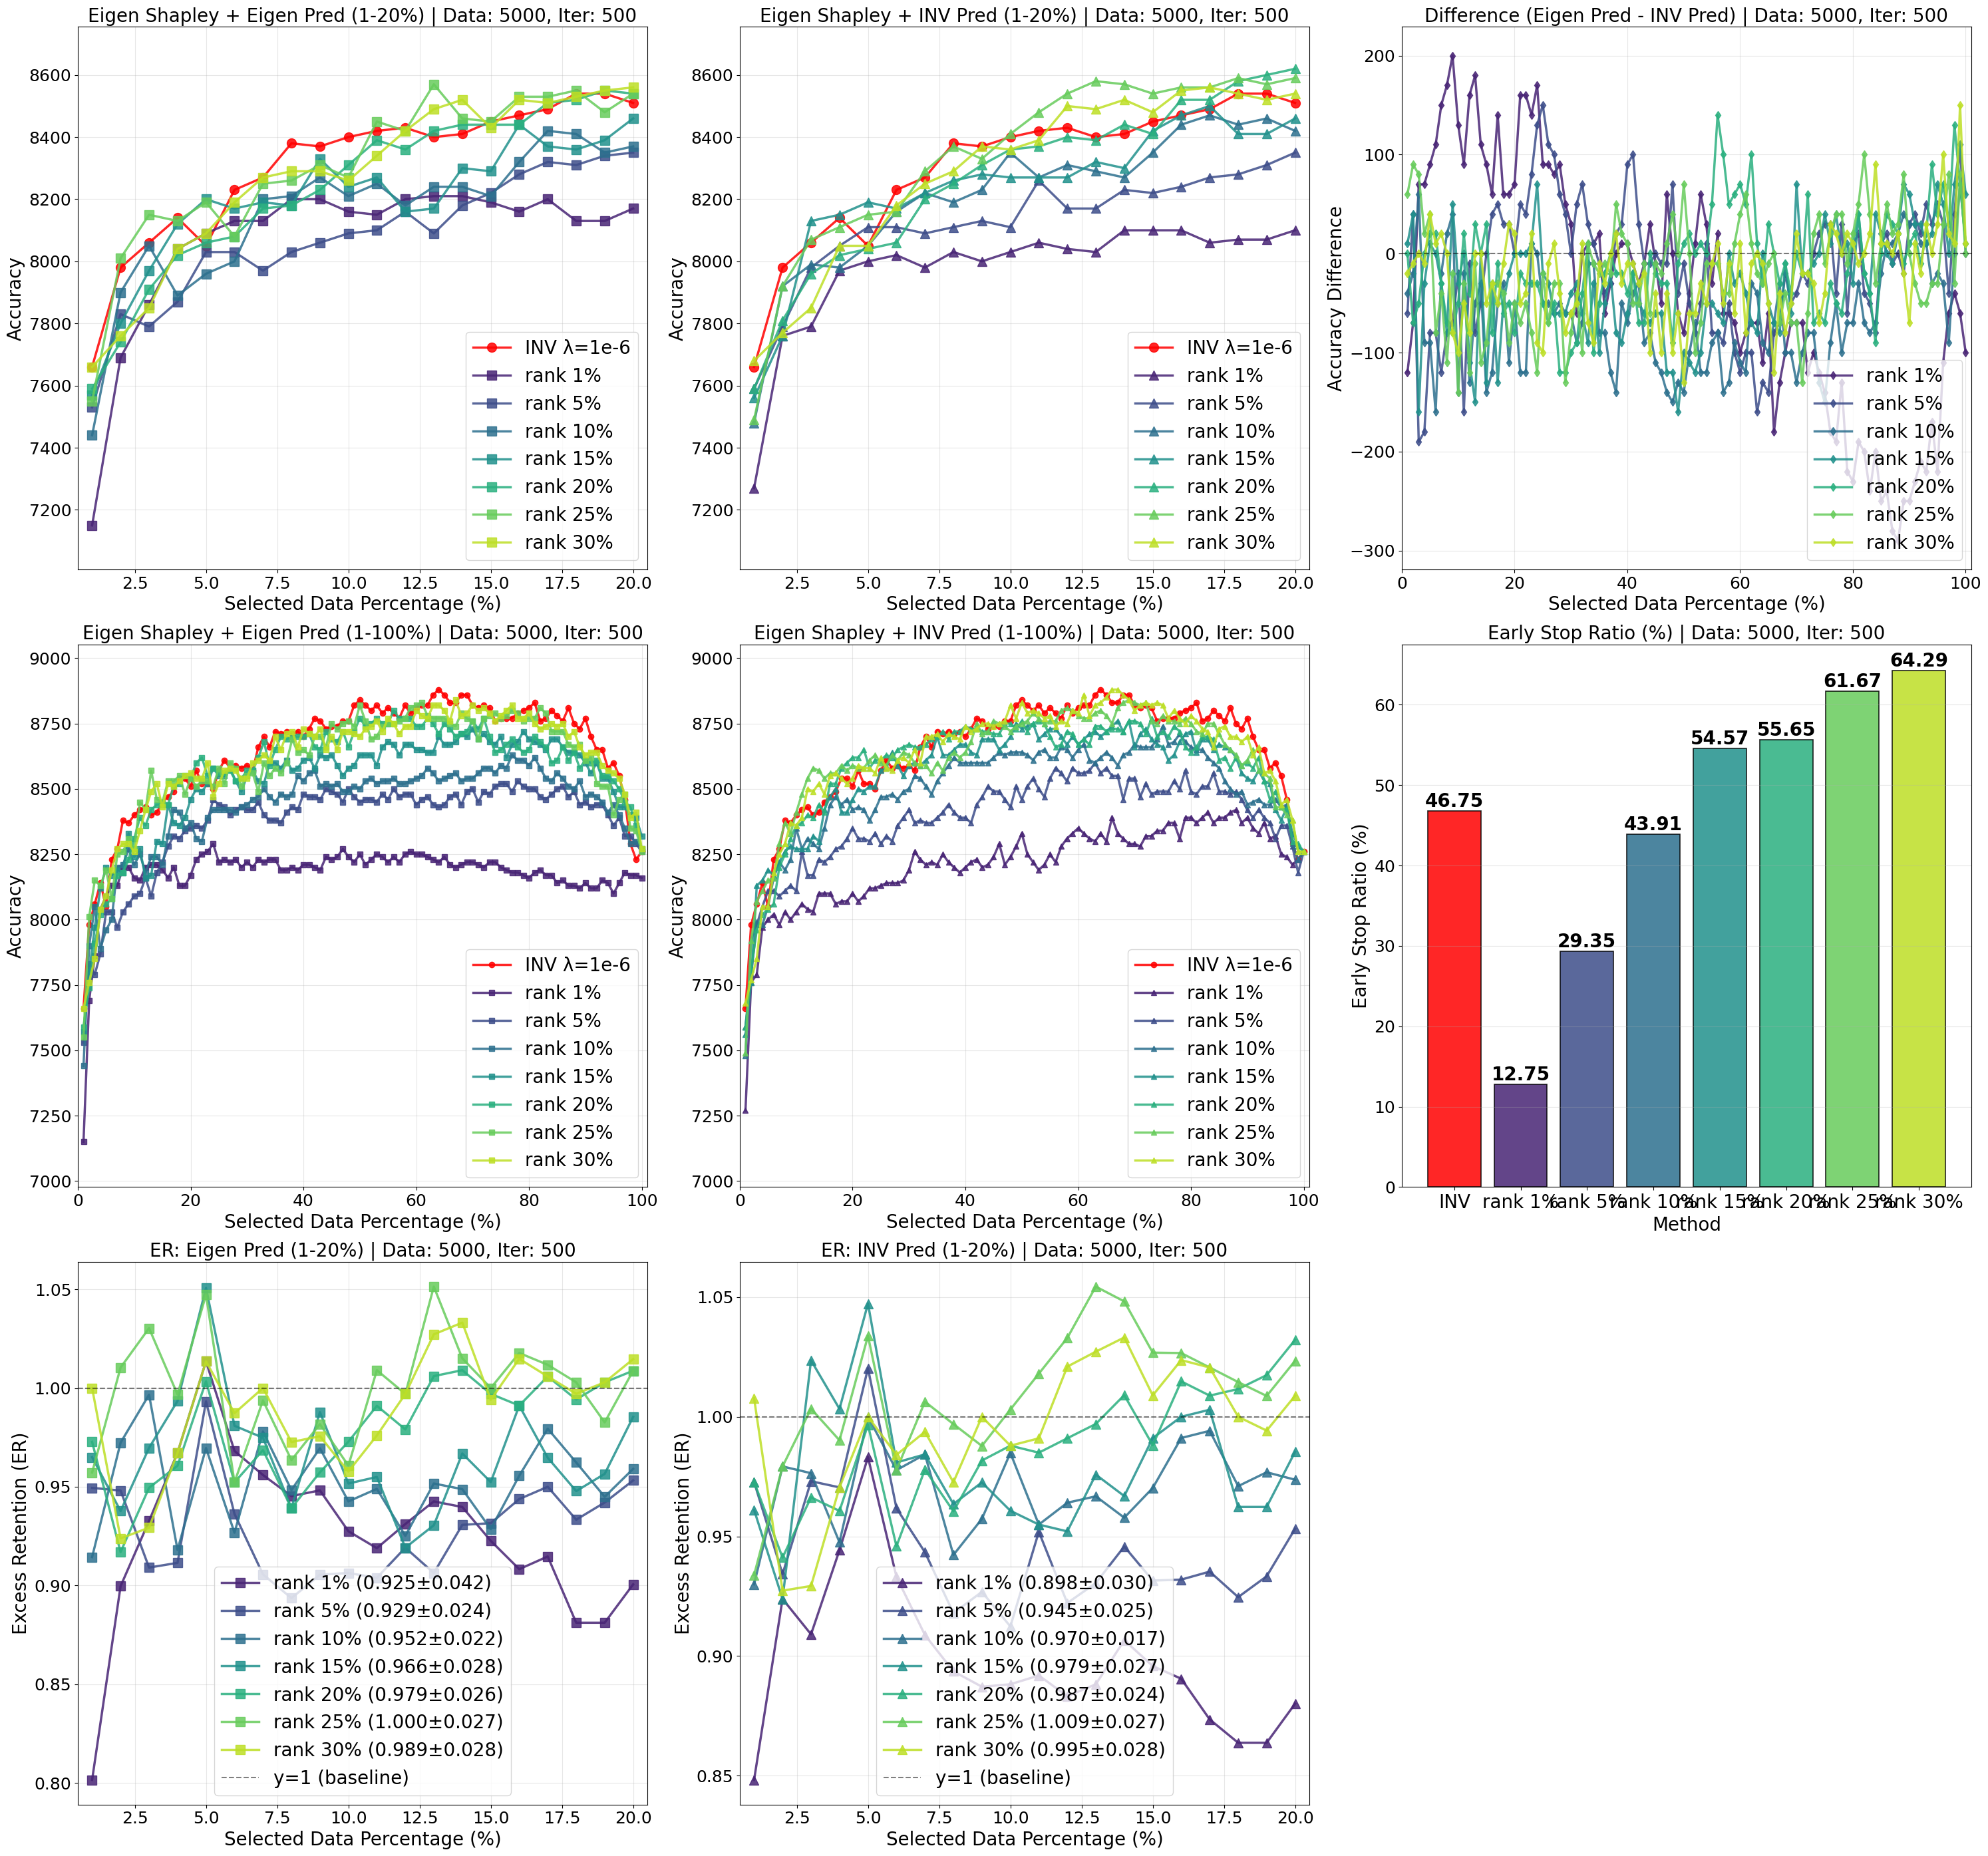

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 5000
iteration = 500
# =========================

selected_dp_percent = [i for i in range(1, 101)]
A_BASE = 5090

# Prediction with top shapley values (shapley eigen 1e-2/prediction eigen 1e-2)
inv_lam1e_6       = [7660, 7980, 8060, 8140, 8050, 8230, 8270, 8380, 8370, 8400, 8420, 8430, 8400, 8410, 8450, 8470, 8490, 8540, 8540, 8510, 8570, 8520, 8520, 8500, 8570, 8610, 8580, 8590, 8580, 8590, 8570, 8660, 8700, 8660, 8720, 8710, 8720, 8710, 8720, 8700, 8730, 8770, 8760, 8730, 8740, 8740, 8760, 8760, 8820, 8840, 8820, 8800, 8820, 8790, 8810, 8790, 8770, 8820, 8790, 8810, 8820, 8820, 8860, 8880, 8860, 8830, 8830, 8860, 8860, 8820, 8810, 8820, 8810, 8760, 8770, 8770, 8770, 8790, 8800, 8810, 8830, 8760, 8770, 8800, 8780, 8760, 8810, 8750, 8730, 8770, 8700, 8650, 8650, 8580, 8600, 8550, 8460, 8290, 8230, 8260]
r1_eigen_lam1e_2  = [7150, 7690, 7860, 8040, 8090, 8130, 8130, 8200, 8200, 8160, 8150, 8200, 8210, 8210, 8190, 8160, 8200, 8130, 8130, 8170, 8230, 8250, 8260, 8290, 8220, 8230, 8220, 8230, 8200, 8220, 8200, 8230, 8220, 8230, 8230, 8190, 8190, 8200, 8190, 8210, 8210, 8200, 8190, 8240, 8230, 8240, 8270, 8240, 8220, 8250, 8210, 8230, 8250, 8240, 8220, 8240, 8220, 8250, 8260, 8250, 8250, 8240, 8230, 8220, 8240, 8210, 8200, 8210, 8220, 8220, 8210, 8200, 8220, 8220, 8200, 8190, 8180, 8180, 8170, 8160, 8180, 8190, 8170, 8170, 8140, 8150, 8130, 8130, 8120, 8140, 8120, 8120, 8150, 8140, 8100, 8140, 8180, 8170, 8170, 8160]
r5_eigen_lam1e_2  = [7530, 7830, 7790, 7870, 8030, 8030, 7970, 8030, 8060, 8090, 8100, 8160, 8090, 8180, 8220, 8280, 8320, 8310, 8340, 8350, 8360, 8350, 8380, 8460, 8440, 8430, 8400, 8420, 8430, 8420, 8420, 8450, 8400, 8380, 8380, 8370, 8410, 8430, 8420, 8480, 8470, 8470, 8460, 8500, 8490, 8480, 8450, 8500, 8470, 8450, 8460, 8460, 8450, 8480, 8460, 8500, 8470, 8480, 8480, 8440, 8460, 8470, 8440, 8430, 8440, 8470, 8480, 8440, 8490, 8500, 8450, 8490, 8480, 8510, 8520, 8520, 8490, 8530, 8510, 8500, 8500, 8470, 8460, 8480, 8500, 8510, 8470, 8490, 8440, 8450, 8430, 8440, 8440, 8400, 8360, 8390, 8320, 8320, 8290, 8260]
r10_eigen_lam1e_2 = [7440, 7900, 8050, 7890, 7960, 8000, 8200, 8210, 8270, 8210, 8250, 8180, 8240, 8240, 8210, 8320, 8420, 8410, 8350, 8370, 8310, 8300, 8390, 8420, 8420, 8420, 8420, 8410, 8430, 8440, 8460, 8470, 8500, 8470, 8450, 8480, 8470, 8480, 8550, 8530, 8560, 8570, 8510, 8520, 8510, 8520, 8490, 8490, 8510, 8500, 8530, 8540, 8520, 8530, 8530, 8540, 8520, 8520, 8530, 8540, 8550, 8580, 8560, 8530, 8540, 8550, 8560, 8530, 8540, 8540, 8560, 8580, 8580, 8560, 8590, 8580, 8630, 8610, 8610, 8590, 8620, 8580, 8540, 8530, 8560, 8540, 8510, 8500, 8530, 8470, 8480, 8470, 8450, 8410, 8440, 8400, 8350, 8290, 8300, 8270]
r15_eigen_lam1e_2 = [7570, 7800, 7970, 8120, 8200, 8170, 8190, 8180, 8330, 8240, 8270, 8160, 8170, 8300, 8290, 8440, 8370, 8360, 8390, 8460, 8500, 8490, 8520, 8580, 8550, 8550, 8580, 8530, 8490, 8550, 8570, 8530, 8520, 8600, 8600, 8580, 8610, 8570, 8580, 8610, 8620, 8580, 8630, 8620, 8630, 8590, 8550, 8580, 8590, 8630, 8630, 8630, 8590, 8660, 8680, 8670, 8630, 8670, 8670, 8650, 8650, 8640, 8640, 8700, 8670, 8670, 8680, 8710, 8700, 8730, 8690, 8710, 8680, 8670, 8700, 8620, 8670, 8680, 8720, 8690, 8680, 8670, 8650, 8690, 8690, 8660, 8640, 8640, 8630, 8600, 8560, 8600, 8540, 8540, 8490, 8430, 8430, 8400, 8390, 8320]
r20_eigen_lam1e_2 = [7590, 7740, 7910, 8020, 8060, 8080, 8170, 8180, 8230, 8310, 8390, 8360, 8420, 8440, 8440, 8440, 8510, 8520, 8550, 8540, 8600, 8620, 8550, 8580, 8560, 8560, 8570, 8530, 8540, 8570, 8570, 8620, 8680, 8590, 8650, 8700, 8690, 8700, 8700, 8700, 8710, 8660, 8650, 8720, 8690, 8680, 8720, 8660, 8720, 8770, 8740, 8750, 8770, 8750, 8750, 8800, 8770, 8770, 8770, 8740, 8740, 8770, 8750, 8710, 8750, 8730, 8700, 8710, 8720, 8760, 8730, 8770, 8700, 8640, 8650, 8670, 8690, 8660, 8640, 8650, 8700, 8680, 8660, 8600, 8610, 8660, 8610, 8640, 8580, 8610, 8600, 8610, 8550, 8550, 8530, 8500, 8450, 8430, 8360, 8270]
r25_eigen_lam1e_2 = [7550, 8010, 8150, 8130, 8190, 8080, 8250, 8260, 8310, 8270, 8450, 8420, 8570, 8460, 8450, 8530, 8530, 8550, 8480, 8540, 8510, 8530, 8530, 8510, 8580, 8520, 8600, 8580, 8510, 8550, 8560, 8490, 8600, 8550, 8580, 8560, 8600, 8690, 8640, 8650, 8630, 8700, 8700, 8660, 8750, 8730, 8750, 8760, 8740, 8820, 8760, 8690, 8700, 8740, 8750, 8750, 8760, 8770, 8810, 8820, 8830, 8780, 8770, 8770, 8770, 8750, 8740, 8790, 8770, 8760, 8690, 8770, 8780, 8790, 8770, 8780, 8800, 8790, 8760, 8770, 8770, 8810, 8790, 8720, 8720, 8720, 8670, 8660, 8670, 8610, 8620, 8520, 8510, 8510, 8400, 8460, 8480, 8350, 8340, 8260]
r30_eigen_lam1e_2 = [7660, 7760, 7850, 8040, 8090, 8190, 8270, 8290, 8290, 8260, 8340, 8420, 8490, 8520, 8430, 8520, 8510, 8530, 8550, 8560, 8540, 8540, 8600, 8470, 8520, 8570, 8580, 8570, 8540, 8540, 8600, 8610, 8630, 8610, 8700, 8650, 8710, 8720, 8660, 8730, 8710, 8700, 8730, 8650, 8700, 8650, 8720, 8720, 8710, 8700, 8730, 8740, 8760, 8720, 8770, 8750, 8710, 8740, 8740, 8800, 8780, 8770, 8820, 8820, 8800, 8760, 8840, 8780, 8790, 8820, 8800, 8810, 8790, 8760, 8780, 8800, 8820, 8770, 8770, 8790, 8750, 8730, 8740, 8750, 8740, 8750, 8700, 8720, 8660, 8630, 8640, 8640, 8590, 8570, 8560, 8540, 8480, 8390, 8410, 8270]

# Prediction with random shapley values (shapley eigen 1e-2/prediction inv 1e-6)
r1_eigen_lam_inv1e_6  = [7270, 7760, 7790, 7970, 8000, 8020, 7980, 8030, 8000, 8030, 8060, 8040, 8030, 8100, 8100, 8100, 8060, 8070, 8070, 8100, 8070, 8090, 8120, 8120, 8130, 8140, 8140, 8140, 8150, 8190, 8260, 8230, 8210, 8220, 8210, 8250, 8220, 8200, 8180, 8200, 8220, 8230, 8200, 8210, 8240, 8290, 8210, 8240, 8280, 8330, 8250, 8220, 8190, 8210, 8250, 8220, 8280, 8310, 8330, 8350, 8330, 8310, 8300, 8330, 8300, 8390, 8330, 8310, 8290, 8290, 8280, 8320, 8320, 8340, 8340, 8370, 8370, 8310, 8390, 8390, 8370, 8390, 8410, 8370, 8390, 8390, 8410, 8420, 8370, 8390, 8350, 8330, 8370, 8310, 8320, 8250, 8240, 8210, 8230, 8260]
r5_eigen_lam_inv1e_6  = [7590, 7790, 7980, 8050, 8110, 8110, 8090, 8110, 8130, 8110, 8260, 8170, 8170, 8230, 8220, 8240, 8270, 8280, 8310, 8350, 8310, 8310, 8300, 8330, 8290, 8320, 8300, 8360, 8390, 8420, 8370, 8380, 8370, 8370, 8390, 8410, 8440, 8410, 8390, 8390, 8370, 8440, 8470, 8510, 8490, 8490, 8460, 8430, 8510, 8460, 8510, 8540, 8500, 8470, 8540, 8580, 8560, 8530, 8580, 8560, 8560, 8570, 8600, 8560, 8580, 8550, 8550, 8460, 8540, 8540, 8470, 8520, 8480, 8490, 8490, 8490, 8530, 8500, 8570, 8490, 8480, 8510, 8510, 8560, 8490, 8490, 8480, 8490, 8460, 8420, 8390, 8420, 8390, 8370, 8310, 8360, 8360, 8280, 8180, 8260]
r10_eigen_lam_inv1e_6 = [7480, 7920, 7990, 7980, 8050, 8160, 8220, 8190, 8230, 8350, 8270, 8310, 8290, 8270, 8350, 8440, 8470, 8440, 8460, 8420, 8430, 8420, 8380, 8420, 8470, 8470, 8480, 8460, 8490, 8500, 8550, 8540, 8510, 8480, 8530, 8560, 8590, 8620, 8600, 8600, 8600, 8600, 8600, 8600, 8620, 8640, 8630, 8640, 8640, 8640, 8630, 8610, 8640, 8650, 8620, 8620, 8660, 8650, 8620, 8650, 8670, 8610, 8600, 8620, 8640, 8620, 8590, 8630, 8640, 8670, 8660, 8660, 8660, 8690, 8740, 8670, 8680, 8710, 8680, 8660, 8650, 8650, 8620, 8600, 8580, 8530, 8500, 8480, 8490, 8440, 8450, 8460, 8440, 8440, 8460, 8430, 8440, 8290, 8230, 8260]
r15_eigen_lam_inv1e_6 = [7560, 7760, 8130, 8150, 8190, 8170, 8220, 8260, 8280, 8270, 8270, 8270, 8320, 8300, 8420, 8470, 8500, 8410, 8410, 8460, 8500, 8490, 8510, 8510, 8570, 8580, 8640, 8590, 8550, 8590, 8600, 8590, 8610, 8630, 8700, 8630, 8630, 8650, 8670, 8670, 8640, 8630, 8690, 8690, 8690, 8650, 8670, 8700, 8750, 8730, 8740, 8750, 8690, 8710, 8730, 8730, 8700, 8670, 8700, 8670, 8690, 8710, 8720, 8700, 8720, 8740, 8760, 8720, 8760, 8660, 8710, 8730, 8690, 8670, 8660, 8610, 8630, 8680, 8710, 8720, 8640, 8690, 8690, 8650, 8670, 8660, 8650, 8620, 8560, 8540, 8530, 8570, 8530, 8520, 8420, 8380, 8430, 8330, 8280, 8260]
r20_eigen_lam_inv1e_6 = [7590, 7810, 7960, 8020, 8040, 8060, 8200, 8250, 8310, 8360, 8370, 8400, 8390, 8440, 8410, 8520, 8520, 8580, 8600, 8620, 8620, 8650, 8580, 8610, 8610, 8630, 8620, 8650, 8660, 8670, 8660, 8660, 8670, 8690, 8700, 8720, 8690, 8720, 8720, 8740, 8730, 8730, 8720, 8720, 8710, 8710, 8750, 8750, 8730, 8760, 8720, 8750, 8760, 8750, 8700, 8660, 8670, 8720, 8710, 8670, 8690, 8670, 8740, 8740, 8720, 8730, 8730, 8720, 8760, 8760, 8750, 8710, 8770, 8700, 8720, 8700, 8740, 8720, 8660, 8640, 8660, 8700, 8700, 8690, 8610, 8620, 8580, 8620, 8590, 8600, 8580, 8620, 8530, 8460, 8490, 8430, 8420, 8300, 8290, 8260]
r25_eigen_lam_inv1e_6 = [7490, 7920, 8070, 8110, 8150, 8160, 8290, 8370, 8330, 8410, 8480, 8540, 8580, 8570, 8540, 8560, 8560, 8590, 8570, 8590, 8580, 8580, 8610, 8630, 8600, 8590, 8630, 8610, 8640, 8630, 8600, 8590, 8590, 8560, 8600, 8570, 8620, 8640, 8620, 8640, 8680, 8750, 8710, 8720, 8760, 8750, 8740, 8720, 8740, 8750, 8760, 8790, 8770, 8750, 8760, 8760, 8800, 8810, 8800, 8780, 8770, 8770, 8790, 8800, 8780, 8750, 8810, 8830, 8840, 8830, 8820, 8830, 8760, 8750, 8780, 8760, 8760, 8750, 8770, 8750, 8720, 8710, 8750, 8750, 8710, 8670, 8650, 8630, 8590, 8610, 8650, 8570, 8560, 8540, 8430, 8430, 8400, 8380, 8260, 8260]
r30_eigen_lam_inv1e_6 = [7680, 7770, 7850, 8050, 8050, 8180, 8250, 8290, 8370, 8360, 8390, 8500, 8490, 8520, 8480, 8550, 8560, 8540, 8520, 8540, 8590, 8580, 8580, 8560, 8620, 8580, 8570, 8610, 8620, 8600, 8650, 8600, 8700, 8700, 8710, 8680, 8710, 8700, 8690, 8740, 8720, 8730, 8750, 8750, 8740, 8750, 8760, 8820, 8770, 8830, 8790, 8800, 8790, 8770, 8780, 8740, 8760, 8750, 8800, 8790, 8860, 8780, 8820, 8830, 8850, 8880, 8880, 8860, 8840, 8800, 8820, 8830, 8820, 8830, 8820, 8770, 8800, 8770, 8750, 8780, 8760, 8730, 8720, 8660, 8730, 8740, 8700, 8700, 8680, 8700, 8630, 8660, 8560, 8570, 8530, 8440, 8460, 8380, 8260, 8260]

inv_early_stop       = [46.75]
r1_eigen_early_stop  = [12.75]
r5_eigen_early_stop  = [29.35]
r10_eigen_early_stop = [43.91]
r15_eigen_early_stop = [54.57]
r20_eigen_early_stop = [55.65]
r25_eigen_early_stop = [61.67]
r30_eigen_early_stop = [64.29]

# ===== Zoom window (small-data regime) =====
ZOOM_PCT = 20                  # show first 20% in the zoom panels
ZOOM_N   = ZOOM_PCT            # selected_dp_percent is 1..100, so first N entries = first N%

# Create figure with 9 subplots (3 rows, 3 columns)
fig, axes = plt.subplots(3, 3, figsize=(30, 28))

# Flatten axes for easier indexing
axes = axes.flatten()

# Prepare color schemes
inv_color = 'red'
eigen_colors = plt.cm.viridis(np.linspace(0.1, 0.9, 7))

# ===== Subplot (1,1): Eigen mode (shapley + prediction) - 1~ZOOM_PCT% =====
ax1 = axes[0]
plot_percent_10 = selected_dp_percent[:ZOOM_N]

# Plot INV
ax1.plot(plot_percent_10, inv_lam1e_6[:ZOOM_N], color=inv_color, linewidth=2.5,
         linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)

# Plot Eigen methods (shapley + prediction both eigen)
eigen_data_1 = [
    (r1_eigen_lam1e_2, 'rank 1%'),
    (r5_eigen_lam1e_2, 'rank 5%'),
    (r10_eigen_lam1e_2, 'rank 10%'),
    (r15_eigen_lam1e_2, 'rank 15%'),
    (r20_eigen_lam1e_2, 'rank 20%'),
    (r25_eigen_lam1e_2, 'rank 25%'),
    (r30_eigen_lam1e_2, 'rank 30%')
]

for i, (data, label) in enumerate(eigen_data_1):
    ax1.plot(plot_percent_10, data[:ZOOM_N], color=eigen_colors[i], linewidth=2.5,
             linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

# Auto calculate ylim for (1,1) and (1,2)
all_data_10_eigen = [inv_lam1e_6[:ZOOM_N]] + [d[0][:ZOOM_N] for d in eigen_data_1]
y_min_10 = min([min(d) for d in all_data_10_eigen])
y_max_10 = max([max(d) for d in all_data_10_eigen])
y_margin_10 = (y_max_10 - y_min_10) * 0.1
ylim_10_min = y_min_10 - y_margin_10
ylim_10_max = y_max_10 + y_margin_10

ax1.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax1.set_ylabel('Accuracy', fontsize=20)
ax1.set_title(f'Eigen Shapley + Eigen Pred (1-{ZOOM_PCT}%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax1.legend(fontsize=20, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.5, ZOOM_PCT + 0.5)
ax1.set_ylim(ylim_10_min, ylim_10_max)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): Eigen shapley + INV prediction - 1~ZOOM_PCT% =====
ax2 = axes[1]

# Plot INV
ax2.plot(plot_percent_10, inv_lam1e_6[:ZOOM_N], color=inv_color, linewidth=2.5,
         linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)

# Plot Eigen shapley + INV prediction
eigen_data_2 = [
    (r1_eigen_lam_inv1e_6, 'rank 1%'),
    (r5_eigen_lam_inv1e_6, 'rank 5%'),
    (r10_eigen_lam_inv1e_6, 'rank 10%'),
    (r15_eigen_lam_inv1e_6, 'rank 15%'),
    (r20_eigen_lam_inv1e_6, 'rank 20%'),
    (r25_eigen_lam_inv1e_6, 'rank 25%'),
    (r30_eigen_lam_inv1e_6, 'rank 30%')
]

for i, (data, label) in enumerate(eigen_data_2):
    ax2.plot(plot_percent_10, data[:ZOOM_N], color=eigen_colors[i], linewidth=2.5,
             linestyle='-', marker='^', markersize=10, label=label, alpha=0.85)

# Update ylim calculation to include inv prediction data
all_data_10_inv = [inv_lam1e_6[:ZOOM_N]] + [d[0][:ZOOM_N] for d in eigen_data_2]
y_min_10_inv = min([min(d) for d in all_data_10_inv])
y_max_10_inv = max([max(d) for d in all_data_10_inv])
# Use same ylim for both (1,1) and (1,2)
ylim_10_min = min(ylim_10_min, y_min_10_inv - (y_max_10_inv - y_min_10_inv) * 0.1)
ylim_10_max = max(ylim_10_max, y_max_10_inv + (y_max_10_inv - y_min_10_inv) * 0.1)

ax2.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax2.set_ylabel('Accuracy', fontsize=20)
ax2.set_title(f'Eigen Shapley + INV Pred (1-{ZOOM_PCT}%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax2.legend(fontsize=20, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0.5, ZOOM_PCT + 0.5)
ax2.set_ylim(ylim_10_min, ylim_10_max)
ax2.tick_params(axis='both', labelsize=18)

# Update ax1 ylim to match ax2
ax1.set_ylim(ylim_10_min, ylim_10_max)

# ===== Subplot (1,3): Difference (Eigen - INV) - 1~100% =====
ax3 = axes[2]

# Calculate differences
diff_data = [
    (np.array(r1_eigen_lam1e_2) - np.array(r1_eigen_lam_inv1e_6), 'rank 1%'),
    (np.array(r5_eigen_lam1e_2) - np.array(r5_eigen_lam_inv1e_6), 'rank 5%'),
    (np.array(r10_eigen_lam1e_2) - np.array(r10_eigen_lam_inv1e_6), 'rank 10%'),
    (np.array(r15_eigen_lam1e_2) - np.array(r15_eigen_lam_inv1e_6), 'rank 15%'),
    (np.array(r20_eigen_lam1e_2) - np.array(r20_eigen_lam_inv1e_6), 'rank 20%'),
    (np.array(r25_eigen_lam1e_2) - np.array(r25_eigen_lam_inv1e_6), 'rank 25%'),
    (np.array(r30_eigen_lam1e_2) - np.array(r30_eigen_lam_inv1e_6), 'rank 30%')
]

for i, (data, label) in enumerate(diff_data):
    ax3.plot(selected_dp_percent, data, color=eigen_colors[i], linewidth=2.5,
             linestyle='-', marker='d', markersize=6, label=label, alpha=0.85)

# Auto calculate ylim for (1,3)
all_diff_data = [d[0] for d in diff_data]
y_min_diff = min([min(d) for d in all_diff_data])
y_max_diff = max([max(d) for d in all_diff_data])
y_margin_diff = max(abs(y_min_diff), abs(y_max_diff)) * 0.1
ylim_diff_min = y_min_diff - y_margin_diff
ylim_diff_max = y_max_diff + y_margin_diff

ax3.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
ax3.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax3.set_ylabel('Accuracy Difference', fontsize=20)
ax3.set_title(f'Difference (Eigen Pred - INV Pred) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.legend(fontsize=20, loc='best')
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, 101)
ax3.set_ylim(ylim_diff_min, ylim_diff_max)
ax3.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,1): Eigen mode (shapley + prediction) - 1~100% =====
ax4 = axes[3]

# Plot INV
ax4.plot(selected_dp_percent, inv_lam1e_6, color=inv_color, linewidth=2.5, 
         linestyle='-', marker='o', markersize=6, label='INV λ=1e-6', alpha=0.85)

# Plot Eigen methods (shapley + prediction both eigen)
for i, (data, label) in enumerate(eigen_data_1):
    ax4.plot(selected_dp_percent, data, color=eigen_colors[i], linewidth=2.5,
             linestyle='-', marker='s', markersize=6, label=label, alpha=0.85)

# Auto calculate ylim for (2,1) and (2,2)
all_data_100_eigen = [inv_lam1e_6] + [d[0] for d in eigen_data_1]
y_min_100 = min([min(d) for d in all_data_100_eigen])
y_max_100 = max([max(d) for d in all_data_100_eigen])
y_margin_100 = (y_max_100 - y_min_100) * 0.1
ylim_100_min = y_min_100 - y_margin_100
ylim_100_max = y_max_100 + y_margin_100

ax4.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax4.set_ylabel('Accuracy', fontsize=20)
ax4.set_title(f'Eigen Shapley + Eigen Pred (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=20, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0, 101)
ax4.set_ylim(ylim_100_min, ylim_100_max)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Eigen shapley + INV prediction - 1~100% =====
ax5 = axes[4]

# Plot INV
ax5.plot(selected_dp_percent, inv_lam1e_6, color=inv_color, linewidth=2.5,
         linestyle='-', marker='o', markersize=6, label='INV λ=1e-6', alpha=0.85)

# Plot Eigen shapley + INV prediction
for i, (data, label) in enumerate(eigen_data_2):
    ax5.plot(selected_dp_percent, data, color=eigen_colors[i], linewidth=2.5,
             linestyle='-', marker='^', markersize=6, label=label, alpha=0.85)

# Update ylim calculation to include inv prediction data
all_data_100_inv = [inv_lam1e_6] + [d[0] for d in eigen_data_2]
y_min_100_inv = min([min(d) for d in all_data_100_inv])
y_max_100_inv = max([max(d) for d in all_data_100_inv])
# Use same ylim for both (2,1) and (2,2)
ylim_100_min = min(ylim_100_min, y_min_100_inv - (y_max_100_inv - y_min_100_inv) * 0.1)
ylim_100_max = max(ylim_100_max, y_max_100_inv + (y_max_100_inv - y_min_100_inv) * 0.1)

ax5.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax5.set_ylabel('Accuracy', fontsize=20)
ax5.set_title(f'Eigen Shapley + INV Pred (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=20, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(0, 101)
ax5.set_ylim(ylim_100_min, ylim_100_max)
ax5.tick_params(axis='both', labelsize=18)

# Update ax4 ylim to match ax5
ax4.set_ylim(ylim_100_min, ylim_100_max)

# ===== Subplot (2,3): Early Stop Ratio =====
ax6 = axes[5]

method_names = ['INV', 'rank 1%', 'rank 5%', 'rank 10%', 'rank 15%', 'rank 20%', 'rank 25%', 'rank 30%']
method_values = [
    inv_early_stop[0],
    r1_eigen_early_stop[0],
    r5_eigen_early_stop[0],
    r10_eigen_early_stop[0],
    r15_eigen_early_stop[0],
    r20_eigen_early_stop[0],
    r25_eigen_early_stop[0],
    r30_eigen_early_stop[0]
]
bar_colors = [inv_color] + list(eigen_colors)

x_pos = np.arange(len(method_names))
bars = ax6.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for i, (bar, value) in enumerate(zip(bars, method_values)):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax6.set_xlabel('Method', fontsize=20)
ax6.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax6.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax6.set_xticks(x_pos)
ax6.set_xticklabels(method_names, fontsize=20)
ax6.grid(True, alpha=0.3, axis='y')
ax6.tick_params(axis='y', labelsize=18)

# ===== Subplot (3,1): ER (Excess Retention) for Eigen Pred - 1~ZOOM_PCT% =====
ax7 = axes[6]
inv_zoom_arr = np.array(inv_lam1e_6[:ZOOM_N])

# Calculate Excess Retention (ER) for eigen prediction mode
er_data_eigen = []
for i, (data, label) in enumerate(eigen_data_1):
    ers = (np.array(data[:ZOOM_N]) - A_BASE) / (inv_zoom_arr - A_BASE)
    er_mean = np.mean(ers)
    er_std = np.std(ers)
    er_data_eigen.append((ers, f'{label} ({er_mean:.3f}±{er_std:.3f})'))

# Plot ER curves
for i, (ers, label) in enumerate(er_data_eigen):
    ax7.plot(plot_percent_10, ers, color=eigen_colors[i], linewidth=2.5,
             linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

# Add y=1 baseline (ER=1 ⇔ eigen accuracy = inv accuracy)
ax7.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax7.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax7.set_ylabel('Excess Retention (ER)', fontsize=20)
ax7.set_title(f'ER: Eigen Pred (1-{ZOOM_PCT}%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax7.legend(fontsize=20, loc='best')
ax7.grid(True, alpha=0.3)
ax7.set_xlim(0.5, ZOOM_PCT + 0.5)
ax7.tick_params(axis='both', labelsize=18)

# ===== Subplot (3,2): ER (Excess Retention) for INV Pred - 1~ZOOM_PCT% =====
ax8 = axes[7]

# Calculate Excess Retention (ER) for inv prediction mode
er_data_inv = []
for i, (data, label) in enumerate(eigen_data_2):
    ers = (np.array(data[:ZOOM_N]) - A_BASE) / (inv_zoom_arr - A_BASE)
    er_mean = np.mean(ers)
    er_std = np.std(ers)
    er_data_inv.append((ers, f'{label} ({er_mean:.3f}±{er_std:.3f})'))

# Plot ER curves
for i, (ers, label) in enumerate(er_data_inv):
    ax8.plot(plot_percent_10, ers, color=eigen_colors[i], linewidth=2.5,
             linestyle='-', marker='^', markersize=10, label=label, alpha=0.85)

# Add y=1 baseline (ER=1 ⇔ eigen accuracy = inv accuracy)
ax8.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax8.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax8.set_ylabel('Excess Retention (ER)', fontsize=20)
ax8.set_title(f'ER: INV Pred (1-{ZOOM_PCT}%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax8.legend(fontsize=20, loc='best')
ax8.grid(True, alpha=0.3)
ax8.set_xlim(0.5, ZOOM_PCT + 0.5)
ax8.tick_params(axis='both', labelsize=18)

# ===== Subplot (3,3): Turn off unused subplot =====
axes[8].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 8530
iteration = 500
# =========================

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values (shapley eigen 1e-2/prediction eigen 1e-2)
inv_lam1e_6       = 
r1_eigen_lam1e_2  = 
r5_eigen_lam1e_2  = 
r10_eigen_lam1e_2 = 
r15_eigen_lam1e_2 = 
r20_eigen_lam1e_2 = 
r25_eigen_lam1e_2 = 
r30_eigen_lam1e_2 = 

# Prediction with random shapley values (shapley eigen 1e-2/prediction inv 1e-6)
r1_eigen_lam_inv1e_6  = 
r5_eigen_lam_inv1e_6  = 
r10_eigen_lam_inv1e_6 = 
r15_eigen_lam_inv1e_6 = 
r20_eigen_lam_inv1e_6 = 
r25_eigen_lam_inv1e_6 = 
r30_eigen_lam_inv1e_6 = 

inv_early_stop       = []
r1_eigen_early_stop  = []
r5_eigen_early_stop  = []
r10_eigen_early_stop = []
r15_eigen_early_stop = []
r20_eigen_early_stop = []
r25_eigen_early_stop = []
r30_eigen_early_stop = []

# Create figure with 9 subplots (3 rows, 3 columns)
fig, axes = plt.subplots(3, 3, figsize=(30, 28))

# Flatten axes for easier indexing
axes = axes.flatten()

# Prepare color schemes - Extended to 10 colors for rank 0.1%, 0.2%, 0.5%, 1%, 5%, 10%, 15%, 20%, 25%, 30%
inv_color = 'red'
eigen_colors = plt.cm.viridis(np.linspace(0.05, 0.95, 10))  # 10 colors for all ranks

# ===== Subplot (1,1): Eigen mode (shapley + prediction) - 1~10% =====
ax1 = axes[0]
plot_percent_10 = selected_dp_percent[:10]

# Plot INV
ax1.plot(plot_percent_10, inv_lam1e_6[:10], color=inv_color, linewidth=2.5, 
         linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)

# Plot Eigen methods (shapley + prediction both eigen) - Including new ranks
eigen_data_1 = [
    (r0_1_eigen_lam1e_2, 'rank 0.1%'),
    (r0_2_eigen_lam1e_2, 'rank 0.2%'),
    (r0_5_eigen_lam1e_2, 'rank 0.5%'),
    (r1_eigen_lam1e_2, 'rank 1%'),
    (r5_eigen_lam1e_2, 'rank 5%'),
    (r10_eigen_lam1e_2, 'rank 10%'),
    (r15_eigen_lam1e_2, 'rank 15%'),
    (r20_eigen_lam1e_2, 'rank 20%'),
    (r25_eigen_lam1e_2, 'rank 25%'),
    (r30_eigen_lam1e_2, 'rank 30%')
]

for i, (data, label) in enumerate(eigen_data_1):
    ax1.plot(plot_percent_10, data[:10], color=eigen_colors[i], linewidth=2.5,
             linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

# Auto calculate ylim for (1,1) and (1,2)
all_data_10_eigen = [inv_lam1e_6[:10]] + [d[0][:10] for d in eigen_data_1]
y_min_10 = min([min(d) for d in all_data_10_eigen])
y_max_10 = max([max(d) for d in all_data_10_eigen])
y_margin_10 = (y_max_10 - y_min_10) * 0.1
ylim_10_min = y_min_10 - y_margin_10
ylim_10_max = y_max_10 + y_margin_10

ax1.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax1.set_ylabel('Accuracy', fontsize=20)
ax1.set_title(f'Eigen Shapley + Eigen Pred (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax1.legend(fontsize=16, loc='best', ncol=2)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.5, 10.5)
ax1.set_ylim(ylim_10_min, ylim_10_max)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): Eigen shapley + INV prediction - 1~10% =====
ax2 = axes[1]

# Plot INV
ax2.plot(plot_percent_10, inv_lam1e_6[:10], color=inv_color, linewidth=2.5,
         linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)

# Plot Eigen shapley + INV prediction - Including new ranks
eigen_data_2 = [
    (r0_1_eigen_lam_inv1e_6, 'rank 0.1%'),
    (r0_2_eigen_lam_inv1e_6, 'rank 0.2%'),
    (r0_5_eigen_lam_inv1e_6, 'rank 0.5%'),
    (r1_eigen_lam_inv1e_6, 'rank 1%'),
    (r5_eigen_lam_inv1e_6, 'rank 5%'),
    (r10_eigen_lam_inv1e_6, 'rank 10%'),
    (r15_eigen_lam_inv1e_6, 'rank 15%'),
    (r20_eigen_lam_inv1e_6, 'rank 20%'),
    (r25_eigen_lam_inv1e_6, 'rank 25%'),
    (r30_eigen_lam_inv1e_6, 'rank 30%')
]

for i, (data, label) in enumerate(eigen_data_2):
    ax2.plot(plot_percent_10, data[:10], color=eigen_colors[i], linewidth=2.5,
             linestyle='-', marker='^', markersize=10, label=label, alpha=0.85)

# Update ylim calculation to include inv prediction data
all_data_10_inv = [inv_lam1e_6[:10]] + [d[0][:10] for d in eigen_data_2]
y_min_10_inv = min([min(d) for d in all_data_10_inv])
y_max_10_inv = max([max(d) for d in all_data_10_inv])
# Use same ylim for both (1,1) and (1,2)
ylim_10_min = min(ylim_10_min, y_min_10_inv - (y_max_10_inv - y_min_10_inv) * 0.1)
ylim_10_max = max(ylim_10_max, y_max_10_inv + (y_max_10_inv - y_min_10_inv) * 0.1)

ax2.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax2.set_ylabel('Accuracy', fontsize=20)
ax2.set_title(f'Eigen Shapley + INV Pred (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax2.legend(fontsize=16, loc='best', ncol=2)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0.5, 10.5)
ax2.set_ylim(ylim_10_min, ylim_10_max)
ax2.tick_params(axis='both', labelsize=18)

# Update ax1 ylim to match ax2
ax1.set_ylim(ylim_10_min, ylim_10_max)

# ===== Subplot (1,3): Difference (Eigen - INV) - 1~100% =====
ax3 = axes[2]

# Calculate differences - Including new ranks
diff_data = [
    (np.array(r0_1_eigen_lam1e_2) - np.array(r0_1_eigen_lam_inv1e_6), 'rank 0.1%'),
    (np.array(r0_2_eigen_lam1e_2) - np.array(r0_2_eigen_lam_inv1e_6), 'rank 0.2%'),
    (np.array(r0_5_eigen_lam1e_2) - np.array(r0_5_eigen_lam_inv1e_6), 'rank 0.5%'),
    (np.array(r1_eigen_lam1e_2) - np.array(r1_eigen_lam_inv1e_6), 'rank 1%'),
    (np.array(r5_eigen_lam1e_2) - np.array(r5_eigen_lam_inv1e_6), 'rank 5%'),
    (np.array(r10_eigen_lam1e_2) - np.array(r10_eigen_lam_inv1e_6), 'rank 10%'),
    (np.array(r15_eigen_lam1e_2) - np.array(r15_eigen_lam_inv1e_6), 'rank 15%'),
    (np.array(r20_eigen_lam1e_2) - np.array(r20_eigen_lam_inv1e_6), 'rank 20%'),
    (np.array(r25_eigen_lam1e_2) - np.array(r25_eigen_lam_inv1e_6), 'rank 25%'),
    (np.array(r30_eigen_lam1e_2) - np.array(r30_eigen_lam_inv1e_6), 'rank 30%')
]

for i, (data, label) in enumerate(diff_data):
    ax3.plot(selected_dp_percent, data, color=eigen_colors[i], linewidth=2.5,
             linestyle='-', marker='d', markersize=6, label=label, alpha=0.85)

# Auto calculate ylim for (1,3)
all_diff_data = [d[0] for d in diff_data]
y_min_diff = min([min(d) for d in all_diff_data])
y_max_diff = max([max(d) for d in all_diff_data])
y_margin_diff = max(abs(y_min_diff), abs(y_max_diff)) * 0.1
ylim_diff_min = y_min_diff - y_margin_diff
ylim_diff_max = y_max_diff + y_margin_diff

ax3.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
ax3.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax3.set_ylabel('Accuracy Difference', fontsize=20)
ax3.set_title(f'Difference (Eigen Pred - INV Pred) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.legend(fontsize=16, loc='best', ncol=2)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, 101)
ax3.set_ylim(ylim_diff_min, ylim_diff_max)
ax3.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,1): Eigen mode (shapley + prediction) - 1~100% =====
ax4 = axes[3]

# Plot INV
ax4.plot(selected_dp_percent, inv_lam1e_6, color=inv_color, linewidth=2.5, 
         linestyle='-', marker='o', markersize=6, label='INV λ=1e-6', alpha=0.85)

# Plot Eigen methods (shapley + prediction both eigen)
for i, (data, label) in enumerate(eigen_data_1):
    ax4.plot(selected_dp_percent, data, color=eigen_colors[i], linewidth=2.5,
             linestyle='-', marker='s', markersize=6, label=label, alpha=0.85)

# Auto calculate ylim for (2,1) and (2,2)
all_data_100_eigen = [inv_lam1e_6] + [d[0] for d in eigen_data_1]
y_min_100 = min([min(d) for d in all_data_100_eigen])
y_max_100 = max([max(d) for d in all_data_100_eigen])
y_margin_100 = (y_max_100 - y_min_100) * 0.1
ylim_100_min = y_min_100 - y_margin_100
ylim_100_max = y_max_100 + y_margin_100

ax4.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax4.set_ylabel('Accuracy', fontsize=20)
ax4.set_title(f'Eigen Shapley + Eigen Pred (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=16, loc='best', ncol=2)
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0, 101)
ax4.set_ylim(ylim_100_min, ylim_100_max)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Eigen shapley + INV prediction - 1~100% =====
ax5 = axes[4]

# Plot INV
ax5.plot(selected_dp_percent, inv_lam1e_6, color=inv_color, linewidth=2.5,
         linestyle='-', marker='o', markersize=6, label='INV λ=1e-6', alpha=0.85)

# Plot Eigen shapley + INV prediction
for i, (data, label) in enumerate(eigen_data_2):
    ax5.plot(selected_dp_percent, data, color=eigen_colors[i], linewidth=2.5,
             linestyle='-', marker='^', markersize=6, label=label, alpha=0.85)

# Update ylim calculation to include inv prediction data
all_data_100_inv = [inv_lam1e_6] + [d[0] for d in eigen_data_2]
y_min_100_inv = min([min(d) for d in all_data_100_inv])
y_max_100_inv = max([max(d) for d in all_data_100_inv])
# Use same ylim for both (2,1) and (2,2)
ylim_100_min = min(ylim_100_min, y_min_100_inv - (y_max_100_inv - y_min_100_inv) * 0.1)
ylim_100_max = max(ylim_100_max, y_max_100_inv + (y_max_100_inv - y_min_100_inv) * 0.1)

ax5.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax5.set_ylabel('Accuracy', fontsize=20)
ax5.set_title(f'Eigen Shapley + INV Pred (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=16, loc='best', ncol=2)
ax5.grid(True, alpha=0.3)
ax5.set_xlim(0, 101)
ax5.set_ylim(ylim_100_min, ylim_100_max)
ax5.tick_params(axis='both', labelsize=18)

# Update ax4 ylim to match ax5
ax4.set_ylim(ylim_100_min, ylim_100_max)

# ===== Subplot (2,3): Early Stop Ratio =====
ax6 = axes[5]

# Updated method names and values with new ranks
method_names = ['INV', '0.1%', '0.2%', '0.5%', '1%', '5%', '10%', '15%', '20%', '25%', '30%']
method_values = [
    inv_early_stop[0],
    r0_1_eigen_early_stop[0],
    r0_2_eigen_early_stop[0],
    r0_5_eigen_early_stop[0],
    r1_eigen_early_stop[0],
    r5_eigen_early_stop[0],
    r10_eigen_early_stop[0],
    r15_eigen_early_stop[0],
    r20_eigen_early_stop[0],
    r25_eigen_early_stop[0],
    r30_eigen_early_stop[0]
]
bar_colors = [inv_color] + list(eigen_colors)

x_pos = np.arange(len(method_names))
bars = ax6.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for i, (bar, value) in enumerate(zip(bars, method_values)):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=14, fontweight='bold')

ax6.set_xlabel('Method', fontsize=20)
ax6.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax6.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax6.set_xticks(x_pos)
ax6.set_xticklabels(method_names, fontsize=14, rotation=45, ha='right')
ax6.grid(True, alpha=0.3, axis='y')
ax6.tick_params(axis='y', labelsize=18)

# ===== Subplot (3,1): Ratio (Eigen / INV) for Eigen Pred - 1~10% =====
ax7 = axes[6]

# Calculate ratios for eigen prediction mode
ratio_data_eigen = []
for i, (data, label) in enumerate(eigen_data_1):
    ratios = np.array(data[:10]) / np.array(inv_lam1e_6[:10])
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ratio_data_eigen.append((ratios, f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})'))

# Plot ratios
for i, (ratios, label) in enumerate(ratio_data_eigen):
    ax7.plot(plot_percent_10, ratios, color=eigen_colors[i], linewidth=2.5,
             linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

# Add y=1 baseline
ax7.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax7.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax7.set_ylabel('Accuracy Ratio (Eigen / INV)', fontsize=20)
ax7.set_title(f'Ratio: Eigen Pred / INV (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax7.legend(fontsize=12, loc='best', ncol=2)
ax7.grid(True, alpha=0.3)
ax7.set_xlim(0.5, 10.5)
ax7.tick_params(axis='both', labelsize=18)

# ===== Subplot (3,2): Ratio (Eigen / INV) for INV Pred - 1~10% =====
ax8 = axes[7]

# Calculate ratios for inv prediction mode
ratio_data_inv = []
for i, (data, label) in enumerate(eigen_data_2):
    ratios = np.array(data[:10]) / np.array(inv_lam1e_6[:10])
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ratio_data_inv.append((ratios, f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})'))

# Plot ratios
for i, (ratios, label) in enumerate(ratio_data_inv):
    ax8.plot(plot_percent_10, ratios, color=eigen_colors[i], linewidth=2.5,
             linestyle='-', marker='^', markersize=10, label=label, alpha=0.85)

# Add y=1 baseline
ax8.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax8.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax8.set_ylabel('Accuracy Ratio (Eigen / INV)', fontsize=20)
ax8.set_title(f'Ratio: INV Pred / INV (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax8.legend(fontsize=12, loc='best', ncol=2)
ax8.grid(True, alpha=0.3)
ax8.set_xlim(0.5, 10.5)
ax8.tick_params(axis='both', labelsize=18)

# ===== Subplot (3,3): Turn off unused subplot =====
axes[8].axis('off')

plt.tight_layout()
plt.show()